# UAV Patrol - 2-UAV MAPPO Training Notebook
> **Architecture**: Centralized Training, Decentralized Execution (MAPPO)  
> **Actors**: shared parameters, per-agent local observation  
> **Critic**: centralized, uses get_global_state()  
> **Observation**: 5x5 local window (80 features/agent)  
> **Shared world**: coverage_map, visit_count, obstacle_map

---
## Table of Contents
1. Install and imports  
2. Map generation  
3. `UAVPatrolEnvIPPO` environment  
4. Sanity check  
5. MAPPO trainer (CTDE)  
6. Run MAPPO training  
7. Evaluation and visualization  
8. MAPPO notes

In [1]:
# -- 1. Install and Imports ----------------------------------------------------
!pip install gymnasium matplotlib numpy -q

import os, random, json, math
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

MASTER_SEED = 42
BACKUP_DIR  = "/kaggle/working/checkpoints_mappo"
os.makedirs(BACKUP_DIR, exist_ok=True)

random.seed(MASTER_SEED)
np.random.seed(MASTER_SEED)
torch.manual_seed(MASTER_SEED)
torch.cuda.manual_seed_all(MASTER_SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)

Device: cpu


## 2. Map Generation

In [2]:
# ── 2. Generate 3 training maps ──────────────────────────────────────────────
import json, os
os.makedirs("/kaggle/working/maps", exist_ok=True)

maps = {
    "map_simple.json": {
        "name": "simple_grid",
        "grid_size": 10,
        "max_steps": 800,
        "start_position": [0, 0],
        "obstacles": [[2,2],[2,3],[2,4],[5,5],[5,6],[7,1],[7,2]],
    },
    "map_mixed.json": {
        "name": "mixed",
        "grid_size": 10,
        "max_steps": 800,
        "start_position": [0, 0],
        "obstacles": [
            [1,3],[1,4],[1,5],[1,6],
            [3,0],[3,1],[3,2],
            [5,4],[5,5],[5,6],[5,7],
            [7,2],[7,3],[7,4],
            [8,7],[8,8],
        ],
    },
    "map_bottleneck.json": {
        "name": "bottleneck",
        "grid_size": 10,
        "max_steps": 1000,
        "start_position": [0, 0],
        "obstacles": [
            [4,0],[4,1],[4,2],[4,3],[4,5],[4,6],[4,7],[4,8],[4,9],
            [2,2],[2,3],[6,6],[6,7],[8,1],[8,2],[8,3],
        ],
    },
}

for fname, cfg in maps.items():
    with open(f"/kaggle/working/maps/{fname}", "w") as f:
        json.dump(cfg, f, indent=2)
    print(f"  ✓  {fname}")

MAP_PATHS = {
    "simple":     "/kaggle/working/maps/map_simple.json",
    "mixed":      "/kaggle/working/maps/map_mixed.json",
    "bottleneck": "/kaggle/working/maps/map_bottleneck.json",
}


  ✓  map_simple.json
  ✓  map_mixed.json
  ✓  map_bottleneck.json


## 3. UAVPatrolEnvIPPO Environment

Key changes from single-agent PPO:

| Feature | Old PPO | New MAPPO |
|---|---|---|
| Agents | 1 | 2 simultaneous |
| Observation | Full map (GxGx3+5) | Local 5x5 window (80 features) |
| Action | `step(action)` | `step([a0,a1])` |
| Reward | scalar | `{0: r0, 1: r1}` |
| Reward scale | 3000/600/80 | 300/60/8 |
| Collision | - | head-on + cross + overlap penalties |
| Team bonus | - | `delta_coverage * alpha` |
| Global state | - | `get_global_state()` for central critic |

**Observation layout (80 features)**:
```
[0:25]  coverage window  5x5 centered at agent
[25:50] obstacle window  5x5
[50:75] visit_norm       5x5
[75:77] own_pos_norm     (x/G, y/G)
[77:79] other_rel_pos    (dx/2G, dy/2G)
[79:80] bfs_dist_norm
```

In [3]:
"""
UAVPatrolEnvIPPO - Research-quality Multi-Agent Environment
===========================================================
Architecture: MAPPO-ready (CTDE) with a centralized critic hook

Design principles
-----------------
* Clean separation: reward logic | observation logic | collision logic
* Simultaneous update - zero sequential bias between agents
* Local 5x5 partial observation (generalizes better than full map)
* Shared world state: coverage_map, visit_count, obstacle_map
* Gymnasium-compatible API with get_global_state() for MAPPO

Reward scale (normalized vs original PPO):
    COMPLETE_BONUS  3000 -> 300
    PARTIAL_SCALE    600 ->  60
    PASSAGE_BONUS     80 ->   8
All other values tuned proportionally.

Observation per agent (5x5 window, flattened):
    coverage_window  25
    obstacle_window  25
    visit_norm       25
    own_pos_norm      2
    other_pos_norm    2   (relative displacement, clipped to [-1,1])
    bfs_dist_norm     1
    -----------------
    Total:           80 features

Action space (per agent): Discrete(4) - Up / Down / Left / Right

Reward dict: {0: r0, 1: r1}
Obs   dict:  {0: obs0, 1: obs1}
"""

import gymnasium as gym
import numpy as np
import json
from collections import deque
from gymnasium import spaces
from typing import Dict, List, Optional, Tuple


# -- Constants -----------------------------------------------------------------

NUM_AGENTS = 2
DIRECTIONS: List[Tuple[int, int]] = [(-1, 0), (1, 0), (0, -1), (0, 1)]   # U D L R
OBS_RADIUS = 4          # 9x9 local window  (2*OBS_RADIUS+1 = 9)
OBS_WIN    = 2 * OBS_RADIUS + 1
LOCAL_SIZE = OBS_WIN * OBS_WIN  # 81 (9x9)


# -----------------------------------------------------------------------------
# Reward logic (pure functions)
# -----------------------------------------------------------------------------

class RewardConfig:
    # ── Per-step signals (tuned for return range ≊[-100, 300]) ────────────────
    EXPLORE_REWARD    = 5.0     # new cell: dominant early signal
    OBSTACLE_PENALTY  = 2.0     # hitting wall
    COVERAGE_SCALE    = 3.0     # coverage_ratio * scale added every step
    FRONTIER_SCALE    = 1.5     # uncovered neighbours bonus
    REVISIT_MULT      = 0.5     # visit_count^2 * mult penalty
    REVISIT_CAP       = 5.0     # max revisit penalty per step
    BFS_SCALE         = 1.0     # 1/(bfs_dist+1) reward toward frontier
    STEP_PENALTY      = 0.05    # small time pressure
    # ── Terminal signals ─────────────────────────────────────────────────────
    COMPLETE_BONUS    = 100.0   # 97%+ coverage achieved
    PARTIAL_SCALE     = 20.0    # coverage_ratio * scale at timeout
    PASSAGE_BONUS     = 3.0     # one-time bottleneck crossing
    # ── Coordination signals ───────────────────────────────────────────────
    COLLISION_PENALTY = 3.0     # head-on or cross collision
    OVERLAP_PENALTY   = 1.0     # adjacent cell proximity penalty
    TEAM_ALPHA        = 2.0     # delta_coverage * alpha (shared CTDE credit)


def compute_explore_reward(
    cfg: RewardConfig,
    coverage: np.ndarray,
    visit_count: np.ndarray,
    x: int,
    y: int,
) -> float:
    """Explore reward or revisit penalty for a single cell visit."""
    if coverage[x, y] == 0:
        return cfg.EXPLORE_REWARD
    penalty = min(visit_count[x, y] ** 2 * cfg.REVISIT_MULT, cfg.REVISIT_CAP)
    return -penalty


def compute_frontier_reward(
    cfg: RewardConfig,
    coverage: np.ndarray,
    obstacles: set,
    grid_size: int,
    x: int,
    y: int,
) -> float:
    """Reward proportional to uncovered neighbors."""
    frontier = sum(
        1
        for dx, dy in DIRECTIONS
        if (0 <= x + dx < grid_size
            and 0 <= y + dy < grid_size
            and coverage[x + dx, y + dy] == 0
            and (x + dx, y + dy) not in obstacles)
    )
    return frontier * cfg.FRONTIER_SCALE


def compute_bfs_reward(cfg: RewardConfig, bfs_dist: int) -> float:
    """Reward for being close to the nearest frontier."""
    if bfs_dist == 0:
        return 3.0
    return cfg.BFS_SCALE / (bfs_dist + 1)


def compute_team_coverage_bonus(
    cfg: RewardConfig,
    prev_coverage_sum: float,
    curr_coverage_sum: float,
) -> float:
    """Shared bonus proportional to new cells covered this step."""
    delta = curr_coverage_sum - prev_coverage_sum
    return delta * cfg.TEAM_ALPHA


# -----------------------------------------------------------------------------
# Collision logic (pure functions)
# -----------------------------------------------------------------------------

def check_collision(pos0: List[int], pos1: List[int]) -> bool:
    """True if both agents land on the same cell."""
    return pos0[0] == pos1[0] and pos0[1] == pos1[1]


def check_cross_collision(
    old0: List[int], new0: List[int],
    old1: List[int], new1: List[int],
) -> bool:
    """True if agents swap cells (cross-collision)."""
    return (new0[0] == old1[0] and new0[1] == old1[1]
            and new1[0] == old0[0] and new1[1] == old0[1])


def check_overlap(pos0: List[int], pos1: List[int]) -> bool:
    """True if Manhattan distance < 2 (adjacent but not same cell)."""
    d = abs(pos0[0] - pos1[0]) + abs(pos0[1] - pos1[1])
    return 0 < d < 2


def apply_collision_penalties(
    cfg: RewardConfig,
    rewards: Dict[int, float],
    old_positions: List[List[int]],
    new_positions: List[List[int]],
) -> None:
    """Apply collision/overlap penalties in-place."""
    p0, p1   = new_positions[0], new_positions[1]
    op0, op1 = old_positions[0], old_positions[1]

    if check_collision(p0, p1):
        rewards[0] -= cfg.COLLISION_PENALTY
        rewards[1] -= cfg.COLLISION_PENALTY

    if check_cross_collision(op0, p0, op1, p1):
        rewards[0] -= cfg.COLLISION_PENALTY
        rewards[1] -= cfg.COLLISION_PENALTY

    if check_overlap(p0, p1):
        rewards[0] -= cfg.OVERLAP_PENALTY
        rewards[1] -= cfg.OVERLAP_PENALTY


# -----------------------------------------------------------------------------
# Observation logic (pure functions)
# -----------------------------------------------------------------------------

def extract_local_window(
    grid: np.ndarray,
    cx: int,
    cy: int,
    radius: int,
    pad_value: float = 0.0,
) -> np.ndarray:
    """
    Extract a (2r+1) x (2r+1) window centered at (cx, cy).
    Pads with pad_value outside grid boundaries.
    """
    g  = grid.shape[0]
    w  = 2 * radius + 1
    out = np.full((w, w), pad_value, dtype=np.float32)
    for di in range(-radius, radius + 1):
        for dj in range(-radius, radius + 1):
            ni, nj = cx + di, cy + dj
            if 0 <= ni < g and 0 <= nj < g:
                out[di + radius, dj + radius] = grid[ni, nj]
    return out.flatten()


def build_obs(
    coverage: np.ndarray,
    obstacle_map: np.ndarray,
    visit_count: np.ndarray,
    agent_positions: List[List[int]],
    agent_id: int,
    bfs_dist: int,
    grid_size: int,
) -> np.ndarray:
    """
    Build the local-window observation vector for one agent.

    Layout (total = LOCAL_SIZE*3 + 2 + 2 + 1 = 248 features):
        [0 : 81]   coverage_window  (9x9 centered at agent)
        [25: 50]   obstacle_window  (5x5, 1=obstacle)
        [50: 75]   visit_norm       (5x5 normalized visit count)
        [75: 77]   own_pos_norm     (x/G, y/G)
        [77: 79]   other_rel_pos    (dx/(2G), dy/(2G) clipped to [-1,1])
        [79: 80]   bfs_dist_norm    (bfs / (2G))
    """
    ax, ay   = agent_positions[agent_id]
    oid      = 1 - agent_id
    ox, oy   = agent_positions[oid]

    mv = visit_count.max()
    vn = visit_count / mv if mv > 0 else visit_count.copy()

    cov_win  = extract_local_window(coverage,     ax, ay, OBS_RADIUS, 0.0)
    obs_win  = extract_local_window(obstacle_map, ax, ay, OBS_RADIUS, 1.0)  # pad=1: wall outside
    vis_win  = extract_local_window(vn,           ax, ay, OBS_RADIUS, 0.0)

    own_pos  = np.array([ax / grid_size, ay / grid_size], dtype=np.float32)

    # Relative position of other agent, normalized and clipped
    rel      = np.clip(
        [(ox - ax) / (grid_size * 2), (oy - ay) / (grid_size * 2)],
        -1.0, 1.0,
    )
    other_pos = np.array(rel, dtype=np.float32)

    bfs_norm  = np.array(
        [min(bfs_dist, grid_size * 2) / (grid_size * 2)],
        dtype=np.float32,
    )

    return np.concatenate([cov_win, obs_win, vis_win, own_pos, other_pos, bfs_norm]).astype(np.float32)


# -----------------------------------------------------------------------------
# Main environment
# -----------------------------------------------------------------------------

class UAVPatrolEnvIPPO(gym.Env):
    """
    Multi-agent UAV patrol environment for 2 UAVs.

    Key properties
    --------------
    * Simultaneous moves - no sequential bias
    * 5x5 local partial observation per agent
    * Shared coverage/visit/obstacle maps
    * Clean reward/observation/collision modules
    * get_global_state() for a MAPPO central critic
    * Gymnasium API: step / reset / render / close
    """

    metadata = {"render_modes": ["human", "ansi"]}

    def __init__(
        self,
        grid_size: int = 10,
        max_steps: int = 600,
        map_file: Optional[str] = None,
        num_agents: int = NUM_AGENTS,
        reward_cfg: Optional[RewardConfig] = None,
    ):
        super().__init__()

        self.reward_cfg = reward_cfg or RewardConfig()

        # -- Load map config --------------------------------------------------
        if map_file:
            with open(map_file) as f:
                config = json.load(f)
            grid_size           = config.get("grid_size", grid_size)
            max_steps           = config.get("max_steps", max_steps)
            self.start_position = config.get("start_position", [0, 0])
            raw_obstacles       = config.get("obstacles", [])
        else:
            self.start_position = [0, 0]
            raw_obstacles       = []

        self.grid_size  = grid_size
        self.max_steps  = max_steps
        self.num_agents = num_agents
        self.obstacles  = set(tuple(o) for o in raw_obstacles)
        self.free_cells = grid_size * grid_size - len(self.obstacles)
        self.passages   = self._detect_passages()

        # -- Pre-build static obstacle map (never changes) --------------------
        self._obstacle_map = np.zeros((grid_size, grid_size), dtype=np.float32)
        for o in self.obstacles:
            self._obstacle_map[o] = 1.0

        # -- Spaces -----------------------------------------------------------
        # obs: LOCAL_SIZE*3 (cov + obs + visit) + 2 (own) + 2 (other_rel) + 1 (bfs)
        obs_size = LOCAL_SIZE * 3 + 5
        single_obs_space = spaces.Box(
            low=-1.0, high=1.0, shape=(obs_size,), dtype=np.float32
        )
        self.observation_space = spaces.Dict(
            {i: single_obs_space for i in range(self.num_agents)}
        )
        self.action_space = spaces.Dict(
            {i: spaces.Discrete(4) for i in range(self.num_agents)}
        )
        # Expose for convenience
        self.single_observation_space = single_obs_space
        self.single_action_space      = spaces.Discrete(4)

        # -- Mutable state (initialized in reset) -----------------------------
        self.agent_positions:     List[List[int]] = [[0, 0], [0, 0]]
        self.coverage:            np.ndarray      = np.zeros((grid_size, grid_size), dtype=np.float32)
        self.visit_count:         np.ndarray      = np.zeros((grid_size, grid_size), dtype=np.float32)
        self._visited_passages:   set             = set()
        self.steps:               int             = 0
        self.trajectory:          List[List[List[int]]] = [[], []]  # per-agent history

    # ---------------------------------------------------------------------
    # Internal helpers
    # ---------------------------------------------------------------------

    def _detect_passages(self) -> set:
        """Detect bottleneck cells (>=70 percent of row/col blocked)."""
        passages, g = set(), self.grid_size
        threshold = max(1, int(g * 0.7))
        for r in range(g):
            if sum(1 for c in range(g) if (r, c) in self.obstacles) >= threshold:
                for c in range(g):
                    if (r, c) not in self.obstacles:
                        passages.add((r, c))
        for c in range(g):
            if sum(1 for r in range(g) if (r, c) in self.obstacles) >= threshold:
                for r in range(g):
                    if (r, c) not in self.obstacles:
                        passages.add((r, c))
        return passages

    def _random_free_cell(self) -> List[int]:
        while True:
            x = int(self.np_random.integers(0, self.grid_size))
            y = int(self.np_random.integers(0, self.grid_size))
            if (x, y) not in self.obstacles:
                return [x, y]

    def _bfs_nearest_frontier(self, agent_id: int) -> int:
        """BFS distance from agent_id position to nearest uncovered cell."""
        sx, sy = self.agent_positions[agent_id]
        if self.coverage[sx, sy] == 0:
            return 0
        visited = {(sx, sy)}
        queue   = deque([(sx, sy, 0)])
        while queue:
            cx, cy, d = queue.popleft()
            for dx, dy in DIRECTIONS:
                nx, ny = cx + dx, cy + dy
                if (0 <= nx < self.grid_size
                        and 0 <= ny < self.grid_size
                        and (nx, ny) not in visited
                        and (nx, ny) not in self.obstacles):
                    if self.coverage[nx, ny] == 0:
                        return d + 1
                    visited.add((nx, ny))
                    queue.append((nx, ny, d + 1))
        return self.grid_size * 2

    def _try_move(self, agent_id: int, action: int) -> Tuple[List[int], bool]:
        """Compute next position without committing. Returns (new_pos, hit_obstacle)."""
        x, y   = self.agent_positions[agent_id]
        dx, dy = DIRECTIONS[action]
        nx     = int(np.clip(x + dx, 0, self.grid_size - 1))
        ny     = int(np.clip(y + dy, 0, self.grid_size - 1))
        if (nx, ny) in self.obstacles:
            return [x, y], True
        return [nx, ny], False

    # ---------------------------------------------------------------------
    # Observation API
    # ---------------------------------------------------------------------

    def _get_obs_for_agent(self, agent_id: int) -> np.ndarray:
        bfs_dist = self._bfs_nearest_frontier(agent_id)
        return build_obs(
            coverage        = self.coverage,
            obstacle_map    = self._obstacle_map,
            visit_count     = self.visit_count,
            agent_positions = self.agent_positions,
            agent_id        = agent_id,
            bfs_dist        = bfs_dist,
            grid_size       = self.grid_size,
        )

    def _get_obs(self) -> Dict[int, np.ndarray]:
        return {i: self._get_obs_for_agent(i) for i in range(self.num_agents)}

    # ---------------------------------------------------------------------
    # Global state for MAPPO central critic
    # ---------------------------------------------------------------------

    def get_global_state(self) -> np.ndarray:
        """
        Concatenated global state for a central critic.

        Layout:
            coverage_flat     G*G
            obstacle_flat     G*G
            visit_norm_flat   G*G
            agent0_pos_norm   2
            agent1_pos_norm   2
            ----------------------
            Total             G*G*3 + 4
        """
        mv = self.visit_count.max()
        vn = (self.visit_count / mv if mv > 0 else self.visit_count).flatten()
        pos0 = np.array(self.agent_positions[0], dtype=np.float32) / self.grid_size
        pos1 = np.array(self.agent_positions[1], dtype=np.float32) / self.grid_size
        return np.concatenate([
            self.coverage.flatten(),
            self._obstacle_map.flatten(),
            vn,
            pos0,
            pos1,
        ]).astype(np.float32)

    # ---------------------------------------------------------------------
    # Gymnasium API
    # ---------------------------------------------------------------------

    def reset(
        self,
        seed: Optional[int] = None,
        options: Optional[dict] = None,
    ) -> Tuple[Dict[int, np.ndarray], dict]:
        super().reset(seed=seed)

        self.coverage          = np.zeros((self.grid_size, self.grid_size), dtype=np.float32)
        self.visit_count       = np.zeros((self.grid_size, self.grid_size), dtype=np.float32)
        self._visited_passages = set()
        self.steps             = 0
        self.trajectory        = [[], []]

        # Spawn agents at distinct free cells with minimum separation
        min_dist = max(1, self.grid_size // 2)
        while True:
            pos0 = self._random_free_cell()
            pos1 = self._random_free_cell()
            if pos0 != pos1:
                dist = abs(pos0[0] - pos1[0]) + abs(pos0[1] - pos1[1])
                if dist >= min_dist:
                    break

        self.agent_positions = [pos0, pos1]

        for pos in self.agent_positions:
            r, c = pos
            self.coverage[r, c]    = 1.0
            self.visit_count[r, c] = 1.0

        for i, pos in enumerate(self.agent_positions):
            self.trajectory[i].append(pos.copy())

        return self._get_obs(), {}

    def step(
        self,
        actions: List[int],
    ) -> Tuple[Dict[int, np.ndarray], Dict[int, float], bool, bool, dict]:
        """
        Simultaneous step for all agents.

        Parameters
        ----------
        actions : [a0, a1]  - one action per agent

        Returns
        -------
        obs        : {agent_id: ndarray}
        rewards    : {agent_id: float}
        terminated : bool
        truncated  : bool
        info       : dict
        """
        assert len(actions) == self.num_agents, \
            f"Expected {self.num_agents} actions, got {len(actions)}"

        cfg           = self.reward_cfg
        old_positions = [p.copy() for p in self.agent_positions]
        rewards       = {i: 0.0 for i in range(self.num_agents)}

        # -- Phase 1: compute new positions simultaneously --------------------
        new_positions = []
        for i in range(self.num_agents):
            new_pos, hit_obs = self._try_move(i, int(actions[i]))
            new_positions.append(new_pos)
            if hit_obs:
                rewards[i] -= cfg.OBSTACLE_PENALTY

        # -- Phase 2: commit all positions -----------------------------------
        self.agent_positions = [p.copy() for p in new_positions]

        # -- Phase 3: collision / overlap penalties --------------------------
        apply_collision_penalties(cfg, rewards, old_positions, new_positions)

        # Anti-stacking: revert both agents to old positions on head-on collision
        if check_collision(new_positions[0], new_positions[1]):
            self.agent_positions = [p.copy() for p in old_positions]
            new_positions = [p.copy() for p in old_positions]

        # -- Phase 4: per-agent rewards + update shared maps -----------------
        prev_coverage_sum = float(self.coverage.sum())

        for i in range(self.num_agents):
            x, y = self.agent_positions[i]
            self.trajectory[i].append([x, y])

            # Update shared maps
            self.visit_count[x, y] += 1

            # Explore / revisit
            rewards[i] += compute_explore_reward(cfg, self.coverage, self.visit_count, x, y)
            self.coverage[x, y] = 1.0  # mark after reward decision

            # Passage bonus (one-time per passage cell, shared set)
            if (x, y) in self.passages and (x, y) not in self._visited_passages:
                rewards[i] += cfg.PASSAGE_BONUS
                self._visited_passages.add((x, y))

            # Frontier reward
            rewards[i] += compute_frontier_reward(cfg, self.coverage, self.obstacles, self.grid_size, x, y)

            # BFS reward
            bfs_dist = self._bfs_nearest_frontier(i)
            rewards[i] += compute_bfs_reward(cfg, bfs_dist)

        # -- Phase 5: coverage reward + team bonus ---------------------------
        curr_coverage_sum = float(self.coverage.sum())
        coverage_ratio    = curr_coverage_sum / self.free_cells
        team_bonus        = compute_team_coverage_bonus(cfg, prev_coverage_sum, curr_coverage_sum)

        for i in range(self.num_agents):
            rewards[i] += coverage_ratio * cfg.COVERAGE_SCALE - cfg.STEP_PENALTY
            rewards[i] += team_bonus

        # -- Phase 6: terminal conditions ------------------------------------
        self.steps   += 1
        terminated    = False
        truncated     = False

        if coverage_ratio >= 0.97:
            for i in range(self.num_agents):
                rewards[i] += cfg.COMPLETE_BONUS
            terminated = True
        elif self.steps >= self.max_steps:
            for i in range(self.num_agents):
                rewards[i] += coverage_ratio * cfg.PARTIAL_SCALE
            truncated = True

        info = {
            "coverage_ratio":  coverage_ratio,
            "steps":           self.steps,
            "agent_positions": [p.copy() for p in self.agent_positions],
            "team_bonus":      team_bonus,
        }
        return self._get_obs(), rewards, terminated, truncated, info

    # ---------------------------------------------------------------------
    # Render
    # ---------------------------------------------------------------------

    def render(self, mode: str = "human") -> Optional[str]:
        """
        Render the grid.
        Symbols:
            .  uncovered free cell
            *  covered cell
            #  obstacle
            0  UAV-0
            1  UAV-1
            X  collision (both on same cell)
        """
        g     = self.grid_size
        # Coverage background
        grid  = np.where(self.coverage > 0, "*", ".").astype(object)
        for o in self.obstacles:
            grid[o] = "#"

        pos0 = tuple(self.agent_positions[0])
        pos1 = tuple(self.agent_positions[1])
        if pos0 == pos1:
            grid[pos0] = "X"
        else:
            grid[pos0] = "0"
            grid[pos1] = "1"

        lines = []
        # Column header
        header = "   " + " ".join(f"{c:1d}" for c in range(g))
        lines.append(header)
        for r in range(g):
            row_str = f"{r:2d} " + " ".join(grid[r])
            lines.append(row_str)

        coverage_ratio = self.coverage.sum() / self.free_cells
        lines.append(
            f"Coverage: {coverage_ratio:.1%}  Steps: {self.steps}  "
            f"UAV0: {self.agent_positions[0]}  UAV1: {self.agent_positions[1]}"
        )

        output = "\n".join(lines)
        if mode == "human":
            print(output)
        return output

    def render_trajectory(self) -> None:
        """
        Print trajectory of both agents overlaid on coverage map.
        Letters show visit-order (capped at 25).
        """
        g    = self.grid_size
        grid = np.where(self.coverage > 0, ".", " ").astype(object)
        for o in self.obstacles:
            grid[o] = "#"

        symbols_0 = "abcdefghijklmnopqrstuvwxyz"
        symbols_1 = "ABCDEFGHIJKLMNOPQRSTUVWXYZ"

        for step_i, pos in enumerate(self.trajectory[0]):
            grid[pos[0], pos[1]] = symbols_0[min(step_i, 25)]
        for step_i, pos in enumerate(self.trajectory[1]):
            grid[pos[0], pos[1]] = symbols_1[min(step_i, 25)]

        print("\nTrajectory  (agent-0: lowercase, agent-1: UPPERCASE)")
        for r in range(g):
            print(" ".join(grid[r]))

    def close(self) -> None:
        pass


# -----------------------------------------------------------------------------
# Sanity checks
# -----------------------------------------------------------------------------

def _sanity_check():
    print("=" * 60)
    print("Sanity check - UAVPatrolEnvIPPO (MAPPO ready)")
    print("=" * 60)

    env = UAVPatrolEnvIPPO(grid_size=10, max_steps=600)
    obs, info = env.reset(seed=42)

    print(f"num_agents       : {env.num_agents}")
    print(f"obs keys         : {list(obs.keys())}")
    print(f"obs[0] shape     : {obs[0].shape}  (expected 80)")
    print(f"obs[1] shape     : {obs[1].shape}")
    print(f"passages         : {len(env.passages)} cells")
    print(f"free_cells       : {env.free_cells}")
    print(f"agent_positions  : {env.agent_positions}")

    # Global state shape
    gs = env.get_global_state()
    print(f"global_state     : {gs.shape}  (for MAPPO critic)")

    # Step
    actions = [env.single_action_space.sample() for _ in range(env.num_agents)]
    obs2, rewards, terminated, truncated, info = env.step(actions)

    print("\nAfter one random step:")
    print(f"  rewards  : {rewards}")
    print(f"  term     : {terminated}  trunc: {truncated}")
    print(f"  coverage : {info['coverage_ratio']:.2%}")

    # Render
    print()
    env.render()

    # Full random episode
    obs, _ = env.reset(seed=0)
    done   = False
    total  = {0: 0.0, 1: 0.0}
    while not done:
        acts = [env.single_action_space.sample() for _ in range(env.num_agents)]
        obs, rews, t, tr, info = env.step(acts)
        for i in range(env.num_agents):
            total[i] += rews[i]
        done = t or tr

    print("\nFull random episode:")
    print(f"  steps    : {env.steps}")
    print(f"  coverage : {info['coverage_ratio']:.1%}")
    print(f"  rewards  : {{ {total[0]:.1f}, {total[1]:.1f} }}")
    print()
    env.render_trajectory()
    print("=" * 60)
    print("OK - UAVPatrolEnvIPPO ready for MAPPO training")
    env.close()


if __name__ == "__main__":
    _sanity_check()

Sanity check - UAVPatrolEnvIPPO (MAPPO ready)
num_agents       : 2
obs keys         : [0, 1]
obs[0] shape     : (248,)  (expected 80)
obs[1] shape     : (248,)
passages         : 0 cells
free_cells       : 100
agent_positions  : [[0, 7], [6, 4]]
global_state     : (304,)  (for MAPPO critic)

After one random step:
  rewards  : {0: 12.57, 1: 14.07}
  term     : False  trunc: False
  coverage : 4.00%

   0 1 2 3 4 5 6 7 8 9
 0 . . . . . . 0 * . .
 1 . . . . . . . . . .
 2 . . . . . . . . . .
 3 . . . . . . . . . .
 4 . . . . . . . . . .
 5 . . . . 1 . . . . .
 6 . . . . * . . . . .
 7 . . . . . . . . . .
 8 . . . . . . . . . .
 9 . . . . . . . . . .
Coverage: 4.0%  Steps: 1  UAV0: [0, 6]  UAV1: [5, 4]

Full random episode:
  steps    : 247
  coverage : 97.0%
  rewards  : { 757.0, 274.9 }


Trajectory  (agent-0: lowercase, agent-1: UPPERCASE)
      z z z z z z z
z z z z z z z z z z
z z z z z z z z Z z
z z Z z z z z z Z Z
z Z Z Z z z z z Z Z
z Z Z Z Z z z z Z Z
L Z Z Z Z Z Z Z Z Z
T Z Z Z 

## 4. Sanity Check

In [4]:
_sanity_check()

Sanity check - UAVPatrolEnvIPPO (MAPPO ready)
num_agents       : 2
obs keys         : [0, 1]
obs[0] shape     : (248,)  (expected 80)
obs[1] shape     : (248,)
passages         : 0 cells
free_cells       : 100
agent_positions  : [[0, 7], [6, 4]]
global_state     : (304,)  (for MAPPO critic)

After one random step:
  rewards  : {0: np.float32(5.04), 1: 12.04}
  term     : False  trunc: False
  coverage : 3.00%

   0 1 2 3 4 5 6 7 8 9
 0 . . . . . . . 0 . .
 1 . . . . . . . . . .
 2 . . . . . . . . . .
 3 . . . . . . . . . .
 4 . . . . . . . . . .
 5 . . . . . . . . . .
 6 . . . . * 1 . . . .
 7 . . . . . . . . . .
 8 . . . . . . . . . .
 9 . . . . . . . . . .
Coverage: 3.0%  Steps: 1  UAV0: [0, 7]  UAV1: [6, 5]

Full random episode:
  steps    : 600
  coverage : 93.0%
  rewards  : { -209.3, -784.2 }


Trajectory  (agent-0: lowercase, agent-1: UPPERCASE)
      z z   z z z z
      z z z z z z z
z z z z z z z z z z
z z Z z z z z z z z
Z Z Z Z z z z z z z
Z Z Z Z Z z z z Z Z
Z Z Z Z Z Z Z Z

## 5. MAPPO Trainer (CTDE)

Training loop:
```
for update in 1..n_updates:
    collect shared rollouts (all agents, all envs)
    compute joint advantages with centralized critic
    PPO update with shared actor + centralized critic
    periodic eval on all maps
```

In [5]:
# -- 5. MAPPO Trainer ---------------------------------------------------------

class SharedActor(nn.Module):
    """Shared actor. Orthogonal init, Tanh activations, small output gain."""
    def __init__(self, obs_dim: int, hidden_dim: int, action_dim: int):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(obs_dim, hidden_dim), nn.Tanh(),
            nn.Linear(hidden_dim, hidden_dim), nn.Tanh(),
            nn.Linear(hidden_dim, action_dim),
        )
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.orthogonal_(m.weight, gain=np.sqrt(2))
                nn.init.zeros_(m.bias)
        # Small output gain -> logits near 0 -> near-uniform softmax at init
        nn.init.orthogonal_(self.net[-1].weight, gain=0.01)

    def forward(self, obs: torch.Tensor) -> torch.Tensor:
        return self.net(obs)


class CentralCritic(nn.Module):
    """Centralised critic. Extra hidden layer; orthogonal init."""
    def __init__(self, global_state_dim: int, hidden_dim: int):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(global_state_dim, hidden_dim), nn.Tanh(),
            nn.Linear(hidden_dim, hidden_dim),        nn.Tanh(),
            nn.Linear(hidden_dim, hidden_dim // 2),   nn.Tanh(),
            nn.Linear(hidden_dim // 2, 1),
        )
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.orthogonal_(m.weight, gain=np.sqrt(2))
                nn.init.zeros_(m.bias)
        nn.init.orthogonal_(self.net[-1].weight, gain=1.0)

    def forward(self, global_state: torch.Tensor) -> torch.Tensor:
        return self.net(global_state)


class MAPPOTrainer:
    """
    MAPPO trainer: shared actor + centralised critic (CTDE).

    Root-cause fixes vs previous version
    --------------------------------------
    1. Per-agent GAE  : rewards_buf stores (T,N,A) not joint sum.
       advantages are computed per-agent with shared V(global_state).
    2. Separate optimisers: lr_critic > lr_actor so V tracks returns fast.
    3. Clipped value loss: PPO-style critic update for stability.
    4. Return normalisation: running std normalises returns before critic.
    5. Orthogonal init: non-random starting policy; entropy decays from 1.38.
    6. Per-agent advantage normalisation (not global over agents+envs).
    7. Linear LR decay + exponential ent_coef decay.
    """

    def __init__(
        self,
        map_file: str,
        total_steps: int     = 4_000_000,
        rollout_len: int     = 256,
        n_envs: int          = 8,
        n_epochs: int        = 4,
        minibatch_size: int  = 512,
        gamma: float         = 0.99,
        gae_lambda: float    = 0.95,
        lr_actor: float      = 3e-4,
        lr_critic: float     = 1e-3,
        clip_range: float    = 0.2,
        hidden_dim: int      = 256,
        ent_coef: float      = 0.01,
        ent_coef_min: float  = 0.001,
        ent_decay: float     = 0.998,
        value_coef: float    = 0.5,
        max_grad_norm: float = 0.5,
        reward_norm: bool    = True,
        seed: int            = MASTER_SEED,
    ):
        self.map_file       = map_file
        self.total_steps    = total_steps
        self.rollout_len    = rollout_len
        self.n_envs         = n_envs
        self.n_epochs       = n_epochs
        self.minibatch_size = minibatch_size
        self.gamma          = gamma
        self.gae_lambda     = gae_lambda
        self.lr_actor       = lr_actor
        self.lr_critic      = lr_critic
        self.clip_range     = clip_range
        self.hidden_dim     = hidden_dim
        self.ent_coef       = ent_coef
        self.ent_coef_min   = ent_coef_min
        self.ent_decay      = ent_decay
        self.value_coef     = value_coef
        self.max_grad_norm  = max_grad_norm
        self.reward_norm    = reward_norm
        self.seed           = seed

        # -- Build envs -------------------------------------------------------
        self.envs = [UAVPatrolEnvIPPO(map_file=map_file) for _ in range(n_envs)]
        self.curr_obs = []
        for n in range(n_envs):
            obs_dict, _ = self.envs[n].reset(seed=self.seed + n)
            self.curr_obs.append(obs_dict)

        # -- Dimensions -------------------------------------------------------
        self.obs_dim          = self.envs[0].single_observation_space.shape[0]
        self.action_dim       = self.envs[0].single_action_space.n
        self.global_state_dim = self.envs[0].get_global_state().shape[0]

        # -- Networks ---------------------------------------------------------
        self.actor  = SharedActor(self.obs_dim, self.hidden_dim, self.action_dim).to(DEVICE)
        self.critic = CentralCritic(self.global_state_dim, self.hidden_dim).to(DEVICE)

        # -- Separate optimisers: critic needs 3-5x higher LR than actor ------
        self.opt_actor  = torch.optim.Adam(self.actor.parameters(),  lr=self.lr_actor,  eps=1e-5)
        self.opt_critic = torch.optim.Adam(self.critic.parameters(), lr=self.lr_critic, eps=1e-5)

        # -- Running return stats for normalisation ---------------------------
        self._ret_mean  = 0.0
        self._ret_var   = 1.0
        self._ret_count = 0

        # -- Logging ----------------------------------------------------------
        self.eval_history  = []
        self._update_count = 0

    # -- Running return normalisation ----------------------------------------
    def _update_ret_rms(self, returns: np.ndarray) -> None:
        """Welford online mean/variance over flattened returns."""
        batch = returns.flatten().astype(np.float64)
        n = len(batch)
        self._ret_count += n
        delta = batch - self._ret_mean
        self._ret_mean += delta.sum() / self._ret_count
        delta2 = batch - self._ret_mean
        self._ret_var = max(1.0, self._ret_var + (delta * delta2).sum())

    def _norm_returns(self, returns: np.ndarray) -> np.ndarray:
        std = np.sqrt(self._ret_var / max(self._ret_count, 1)) + 1e-8
        return np.clip(returns / std, -10.0, 10.0)

    # -- Policy --------------------------------------------------------------
    def _policy(self, obs_batch: np.ndarray, deterministic: bool = False):
        obs_t  = torch.as_tensor(obs_batch, dtype=torch.float32, device=DEVICE)
        logits = self.actor(obs_t)
        dist   = torch.distributions.Categorical(logits=logits)
        if deterministic:
            actions = torch.argmax(logits, dim=-1)
        else:
            actions = dist.sample()
        logp = dist.log_prob(actions)
        return actions, logp, dist.entropy()

    # -- Rollout collection --------------------------------------------------
    def _collect_rollouts(self):
        T = self.rollout_len; N = self.n_envs; A = NUM_AGENTS
        obs_dim = self.obs_dim; gdim = self.global_state_dim

        obs_buf     = np.zeros((T, N, A, obs_dim), dtype=np.float32)
        actions_buf = np.zeros((T, N, A),          dtype=np.int64)
        logp_buf    = np.zeros((T, N, A),          dtype=np.float32)
        # KEY FIX: per-agent rewards, NOT joint sum
        rewards_buf = np.zeros((T, N, A),          dtype=np.float32)
        dones_buf   = np.zeros((T, N),             dtype=np.float32)
        values_buf  = np.zeros((T, N),             dtype=np.float32)
        global_buf  = np.zeros((T, N, gdim),       dtype=np.float32)

        ep_rewards = []; ep_coverages = []; ep_overlaps = []; ep_entropies = []
        running_r   = np.zeros(N, dtype=np.float32)
        running_ent = np.zeros(N, dtype=np.float32)
        running_ovl = np.zeros(N, dtype=np.float32)
        running_stp = np.zeros(N, dtype=np.float32)

        for t in range(T):
            for n, env in enumerate(self.envs):
                obs_dict     = self.curr_obs[n]
                obs_batch    = np.stack([obs_dict[0], obs_dict[1]], axis=0)
                global_state = env.get_global_state()

                with torch.no_grad():
                    actions, logp, entropy = self._policy(obs_batch, deterministic=False)
                    value = self.critic(
                        torch.as_tensor(global_state, dtype=torch.float32, device=DEVICE)
                    ).squeeze(-1)

                actions_list = [int(actions[0]), int(actions[1])]
                next_obs, rewards, terminated, truncated, info = env.step(actions_list)
                done = terminated or truncated

                # Store per-agent rewards (not summed)
                per_agent_r = np.array([float(rewards[0]), float(rewards[1])], dtype=np.float32)

                obs_buf[t, n]     = obs_batch
                actions_buf[t, n] = actions.cpu().numpy()
                logp_buf[t, n]    = logp.detach().cpu().numpy()
                rewards_buf[t, n] = per_agent_r
                dones_buf[t, n]   = 1.0 if done else 0.0
                values_buf[t, n]  = value.detach().cpu().item()
                global_buf[t, n]  = global_state

                running_r[n]   += float(per_agent_r.sum())
                running_ent[n] += float(entropy.mean().cpu().item())
                running_stp[n] += 1.0
                if check_collision(env.agent_positions[0], env.agent_positions[1]):
                    running_ovl[n] += 1
                elif check_overlap(env.agent_positions[0], env.agent_positions[1]):
                    running_ovl[n] += 1

                if done:
                    ep_rewards.append(float(running_r[n]))
                    ep_coverages.append(float(info["coverage_ratio"] * 100.0))
                    ep_overlaps.append(float(running_ovl[n]))
                    ep_entropies.append(float(running_ent[n] / max(running_stp[n], 1)))
                    running_r[n] = running_ent[n] = running_ovl[n] = running_stp[n] = 0.0
                    new_obs, _ = env.reset(seed=self.seed + n + t * N)
                    self.curr_obs[n] = new_obs
                else:
                    self.curr_obs[n] = next_obs

        # Bootstrap last values
        last_values = np.zeros(N, dtype=np.float32)
        for n, env in enumerate(self.envs):
            gs = env.get_global_state()
            with torch.no_grad():
                last_values[n] = self.critic(
                    torch.as_tensor(gs, dtype=torch.float32, device=DEVICE)
                ).squeeze(-1).cpu().item()

        rollouts = {
            "obs": obs_buf, "actions": actions_buf, "logp": logp_buf,
            "rewards": rewards_buf, "dones": dones_buf, "values": values_buf,
            "global": global_buf, "last_values": last_values,
        }
        stats = {
            "ep_joint_reward": float(np.mean(ep_rewards))   if ep_rewards   else 0.0,
            "ep_coverage":     float(np.mean(ep_coverages)) if ep_coverages else 0.0,
            "ep_overlap":      float(np.mean(ep_overlaps))  if ep_overlaps  else 0.0,
            "ep_entropy":      float(np.mean(ep_entropies)) if ep_entropies else 0.0,
        }
        return rollouts, stats

    # -- Per-agent GAE with shared central V ----------------------------------
    def _compute_gae(self, rewards, dones, values, last_values):
        """
        rewards : (T, N, A) per-agent
        values  : (T, N)    V(global_state) -- same V for both agents (MAPPO)
        returns : (T, N, A) per-agent discounted returns
        adv     : (T, N, A) per-agent advantages from shared critic
        """
        T, N, A = rewards.shape
        advantages = np.zeros((T, N, A), dtype=np.float32)
        lastgaelam = np.zeros((N, A),    dtype=np.float32)

        for t in reversed(range(T)):
            next_val = last_values if t == T - 1 else values[t + 1]  # (N,)
            mask  = 1.0 - dones[t]                                    # (N,)
            # Each agent uses shared V but its own reward (MAPPO)
            delta = (rewards[t]                                        # (N,A)
                     + self.gamma * next_val[:, None] * mask[:, None]
                     - values[t][:, None])
            lastgaelam = delta + self.gamma * self.gae_lambda * mask[:, None] * lastgaelam
            advantages[t] = lastgaelam

        returns = advantages + values[:, :, None]
        return advantages, returns

    # -- PPO update ----------------------------------------------------------
    def _ppo_update(self, rollouts, n_updates_total):
        obs           = rollouts["obs"]         # (T,N,A,obs_dim)
        actions       = rollouts["actions"]     # (T,N,A)
        logp_old      = rollouts["logp"]        # (T,N,A)
        rewards       = rollouts["rewards"]     # (T,N,A) per-agent
        dones         = rollouts["dones"]       # (T,N)
        values        = rollouts["values"]      # (T,N)
        global_states = rollouts["global"]      # (T,N,gdim)
        last_values   = rollouts["last_values"] # (N,)

        advantages, returns = self._compute_gae(rewards, dones, values, last_values)

        # Return normalisation
        if self.reward_norm:
            self._update_ret_rms(returns)
            returns_n = self._norm_returns(returns)
        else:
            returns_n = returns

        T, N, A, obs_dim = obs.shape
        gdim      = self.global_state_dim
        B         = T * N  # samples

        obs_flat     = obs.reshape(B, A, obs_dim)
        actions_flat = actions.reshape(B, A)
        logp_flat    = logp_old.reshape(B, A)
        adv_flat     = advantages.reshape(B, A)   # (B, A) per-agent
        ret_flat_a   = returns_n.reshape(B, A)    # (B, A) per-agent
        # Critic target: mean over agents (shared V)
        ret_crit     = returns_n.mean(axis=2).reshape(B)   # (B,)
        val_old_flat = values.reshape(B)                    # (B,) for clip
        global_flat  = global_states.reshape(B, gdim)      # (B, gdim)

        # Per-agent advantage normalisation (not mixed across agents)
        adv_norm = np.zeros_like(adv_flat)
        for a in range(A):
            mu  = adv_flat[:, a].mean()
            std = adv_flat[:, a].std()
            adv_norm[:, a] = np.clip((adv_flat[:, a] - mu) / (std + 1e-8), -5.0, 5.0)

        indices = np.arange(B)
        actor_losses = []; critic_losses = []; entropies = []

        for _ in range(self.n_epochs):
            np.random.shuffle(indices)
            for start in range(0, B, self.minibatch_size):
                mb = indices[start: start + self.minibatch_size]

                obs_mb     = torch.as_tensor(obs_flat[mb],     dtype=torch.float32, device=DEVICE)
                act_mb     = torch.as_tensor(actions_flat[mb], dtype=torch.int64,   device=DEVICE)
                logp_mb    = torch.as_tensor(logp_flat[mb],    dtype=torch.float32, device=DEVICE)
                adv_mb     = torch.as_tensor(adv_norm[mb],     dtype=torch.float32, device=DEVICE)
                ret_mb     = torch.as_tensor(ret_crit[mb],     dtype=torch.float32, device=DEVICE)
                val_old_mb = torch.as_tensor(val_old_flat[mb], dtype=torch.float32, device=DEVICE)
                glob_mb    = torch.as_tensor(global_flat[mb],  dtype=torch.float32, device=DEVICE)

                # ── Actor loss (per-agent, then averaged) ──────────────────────────
                total_actor_loss = torch.tensor(0.0, device=DEVICE)
                total_entropy    = torch.tensor(0.0, device=DEVICE)
                for agent_id in range(A):
                    logits = self.actor(obs_mb[:, agent_id, :])
                    dist   = torch.distributions.Categorical(logits=logits)
                    logp   = dist.log_prob(act_mb[:, agent_id])
                    ratio  = torch.exp(logp - logp_mb[:, agent_id])
                    surr1  = ratio * adv_mb[:, agent_id]
                    surr2  = torch.clamp(ratio,
                                         1.0 - self.clip_range,
                                         1.0 + self.clip_range) * adv_mb[:, agent_id]
                    total_actor_loss = total_actor_loss + (-torch.min(surr1, surr2).mean())
                    total_entropy    = total_entropy    + dist.entropy().mean()

                total_actor_loss = total_actor_loss / A
                total_entropy    = total_entropy    / A
                actor_loss = total_actor_loss - self.ent_coef * total_entropy

                self.opt_actor.zero_grad()
                actor_loss.backward()
                nn.utils.clip_grad_norm_(self.actor.parameters(), self.max_grad_norm)
                self.opt_actor.step()

                # ── Critic loss (PPO-style clipped value loss) ─────────────────────
                val_pred = self.critic(glob_mb).squeeze(-1)
                val_pred_clipped = val_old_mb + torch.clamp(
                    val_pred - val_old_mb, -self.clip_range, self.clip_range
                )
                critic_loss = self.value_coef * torch.max(
                    (val_pred         - ret_mb).pow(2),
                    (val_pred_clipped - ret_mb).pow(2),
                ).mean()

                self.opt_critic.zero_grad()
                critic_loss.backward()
                nn.utils.clip_grad_norm_(self.critic.parameters(), self.max_grad_norm)
                self.opt_critic.step()

                actor_losses.append(float(total_actor_loss.detach()))
                critic_losses.append(float(critic_loss.detach()))
                entropies.append(float(total_entropy.detach()))

        # Linear LR decay
        frac = max(1e-4, 1.0 - self._update_count / max(n_updates_total, 1))
        for pg in self.opt_actor.param_groups:  pg["lr"] = self.lr_actor  * frac
        for pg in self.opt_critic.param_groups: pg["lr"] = self.lr_critic * frac
        self._update_count += 1

        return {
            "actor_loss":  float(np.mean(actor_losses)),
            "critic_loss": float(np.mean(critic_losses)),
            "entropy":     float(np.mean(entropies)),
        }

    # -- Evaluation ----------------------------------------------------------
    def evaluate_map(self, map_file: str, n_episodes: int = 8) -> dict:
        joint_rewards = []; coverages = []; overlaps = []; entropies = []
        for ep in range(n_episodes):
            env = UAVPatrolEnvIPPO(map_file=map_file)
            obs, _ = env.reset(seed=1000 + ep)
            done = False
            total_r = 0.0; overlap = 0; ent_sum = 0.0; steps = 0
            while not done:
                obs_batch = np.stack([obs[0], obs[1]], axis=0)
                with torch.no_grad():
                    actions, _, entropy = self._policy(obs_batch, deterministic=True)
                obs, rewards, t, tr, _ = env.step([int(actions[0]), int(actions[1])])
                total_r += float(rewards[0] + rewards[1])
                if check_collision(env.agent_positions[0], env.agent_positions[1]):
                    overlap += 1
                elif check_overlap(env.agent_positions[0], env.agent_positions[1]):
                    overlap += 1
                ent_sum += float(entropy.mean().cpu().item())
                steps += 1; done = t or tr
            joint_rewards.append(total_r)
            coverages.append(env.coverage.sum() / env.free_cells * 100.0)
            overlaps.append(overlap)
            entropies.append(ent_sum / max(steps, 1))
        return {
            "joint_reward": float(np.mean(joint_rewards)),
            "coverage":     float(np.mean(coverages)),
            "overlap":      float(np.mean(overlaps)),
            "entropy":      float(np.mean(entropies)),
        }

    def evaluate_all_maps(self, n_episodes: int = 8) -> dict:
        results = {}
        for name, mp in MAP_PATHS.items():
            results[name] = self.evaluate_map(mp, n_episodes=n_episodes)
        results["mean"] = {
            "joint_reward": float(np.mean([results[m]["joint_reward"] for m in MAP_PATHS])),
            "coverage":     float(np.mean([results[m]["coverage"]     for m in MAP_PATHS])),
            "overlap":      float(np.mean([results[m]["overlap"]      for m in MAP_PATHS])),
            "entropy":      float(np.mean([results[m]["entropy"]      for m in MAP_PATHS])),
        }
        return results

    # -- Main training loop --------------------------------------------------
    def train(self, eval_interval: int = 10) -> None:
        steps_per_update = self.rollout_len * self.n_envs
        n_updates = max(1, self.total_steps // steps_per_update)

        print("=" * 70)
        print(f"MAPPO Training — {n_updates} updates × {steps_per_update} steps/update")
        print(f"  obs_dim={self.obs_dim}  state_dim={self.global_state_dim}")
        print(f"  lr_actor={self.lr_actor}  lr_critic={self.lr_critic}")
        print(f"  ent_coef={self.ent_coef:.4f}→{self.ent_coef_min}  decay={self.ent_decay}")
        print(f"  Map: {self.map_file}")
        print("=" * 70)

        for update in range(1, n_updates + 1):
            rollouts, stats = self._collect_rollouts()
            # Exponential entropy decay
            self.ent_coef = max(self.ent_coef_min, self.ent_coef * self.ent_decay)
            metrics = self._ppo_update(rollouts, n_updates)

            if update % eval_interval == 0 or update == 1 or update == n_updates:
                eval_res = self.evaluate_all_maps(n_episodes=5)
                record = {
                    "update":             update,
                    "train_joint_reward": stats["ep_joint_reward"],
                    "train_coverage":     stats["ep_coverage"],
                    "train_overlap":      stats["ep_overlap"],
                    "train_entropy":      stats["ep_entropy"],
                    "eval":               eval_res,
                    "actor_loss":         metrics["actor_loss"],
                    "critic_loss":        metrics["critic_loss"],
                    "entropy":            metrics["entropy"],
                    "ent_coef":           self.ent_coef,
                }
                self.eval_history.append(record)
                me = eval_res["mean"]
                print(
                    f"  upd {update:4d}/{n_updates} | "
                    f"cov={me['coverage']:.1f}% | "
                    f"R={me['joint_reward']:.0f} | "
                    f"ovlp={me['overlap']:.1f} | "
                    f"ent={me['entropy']:.3f} | "
                    f"ent_coef={self.ent_coef:.4f} | "
                    f"a_loss={metrics['actor_loss']:.4f}"
                )

        print("\n" + "=" * 70)
        print("MAPPO Training complete!")
        print("=" * 70)

    def save(self, prefix: str = "mappo_uav") -> None:
        torch.save(self.actor.state_dict(),  f"{BACKUP_DIR}/{prefix}_actor.pt")
        torch.save(self.critic.state_dict(), f"{BACKUP_DIR}/{prefix}_critic.pt")
        print(f"  Saved → {BACKUP_DIR}/{prefix}_actor/critic.pt")

    def load(self, prefix: str = "mappo_uav") -> None:
        self.actor.load_state_dict(torch.load(f"{BACKUP_DIR}/{prefix}_actor.pt",  map_location=DEVICE))
        self.critic.load_state_dict(torch.load(f"{BACKUP_DIR}/{prefix}_critic.pt", map_location=DEVICE))
        print(f"  Loaded ← {BACKUP_DIR}/{prefix}")


## 6. Run MAPPO Training

In [6]:
# -- 6. Run training on bottleneck map (hardest) ------------------------------
trainer = MAPPOTrainer(
    map_file       = MAP_PATHS["bottleneck"],
    total_steps    = 4_000_000,
    rollout_len    = 256,
    n_envs         = 8,
    n_epochs       = 4,
    minibatch_size = 512,
    gamma          = 0.99,
    gae_lambda     = 0.95,
    lr_actor       = 3e-4,
    lr_critic      = 1e-3,
    clip_range     = 0.2,
    hidden_dim     = 256,
    ent_coef       = 0.01,
    ent_coef_min   = 0.001,
    ent_decay      = 0.998,
    reward_norm    = True,
    seed           = MASTER_SEED,
)
trainer.train(eval_interval=10)
trainer.save("mappo_uav_final")


MAPPO Training — 1953 updates × 2048 steps/update
  obs_dim=248  state_dim=304
  lr_actor=0.0003  lr_critic=0.001
  ent_coef=0.0100→0.001  decay=0.998
  Map: /kaggle/working/maps/map_bottleneck.json
  upd    1/1953 | cov=13.8% | R=-5943 | ovlp=158.1 | ent=1.379 | ent_coef=0.0100 | a_loss=-0.0044
  upd   10/1953 | cov=14.5% | R=-4684 | ovlp=0.2 | ent=1.329 | ent_coef=0.0098 | a_loss=-0.0059
  upd   20/1953 | cov=32.2% | R=-5091 | ovlp=0.2 | ent=1.174 | ent_coef=0.0096 | a_loss=-0.0068
  upd   30/1953 | cov=71.2% | R=-3756 | ovlp=145.5 | ent=1.037 | ent_coef=0.0094 | a_loss=-0.0053
  upd   40/1953 | cov=68.0% | R=-3181 | ovlp=1.4 | ent=0.875 | ent_coef=0.0092 | a_loss=-0.0072
  upd   50/1953 | cov=77.5% | R=-3820 | ovlp=91.1 | ent=0.824 | ent_coef=0.0090 | a_loss=-0.0067
  upd   60/1953 | cov=70.9% | R=-3399 | ovlp=3.6 | ent=0.763 | ent_coef=0.0089 | a_loss=-0.0067
  upd   70/1953 | cov=76.9% | R=-4142 | ovlp=55.7 | ent=0.816 | ent_coef=0.0087 | a_loss=-0.0070
  upd   80/1953 | cov=69.5%

## 7. Evaluation and Visualization

In [7]:
# -- 7a. Quick joint eval function --------------------------------------------
def quick_joint_eval(trainer: MAPPOTrainer, map_file: str, n_episodes: int = 5) -> dict:
    return trainer.evaluate_map(map_file, n_episodes=n_episodes)


# -- 7b. Final joint eval on all maps ------------------------------------------
print("\n=== Final Joint Evaluation ===")
for name, mp in MAP_PATHS.items():
    res = quick_joint_eval(trainer, mp, n_episodes=10)
    print(
        f"  {name:12s}: "
        f"reward={res['joint_reward']:.1f}  "
        f"coverage={res['coverage']:.1f}%  "
        f"overlap={res['overlap']:.2f}  "
        f"entropy={res['entropy']:.3f}"
    )


=== Final Joint Evaluation ===
  simple      : reward=-1264.1  coverage=86.9%  overlap=3.00  entropy=0.612
  mixed       : reward=-3171.1  coverage=80.6%  overlap=0.70  entropy=0.699
  bottleneck  : reward=1282.6  coverage=97.9%  overlap=1.40  entropy=0.093


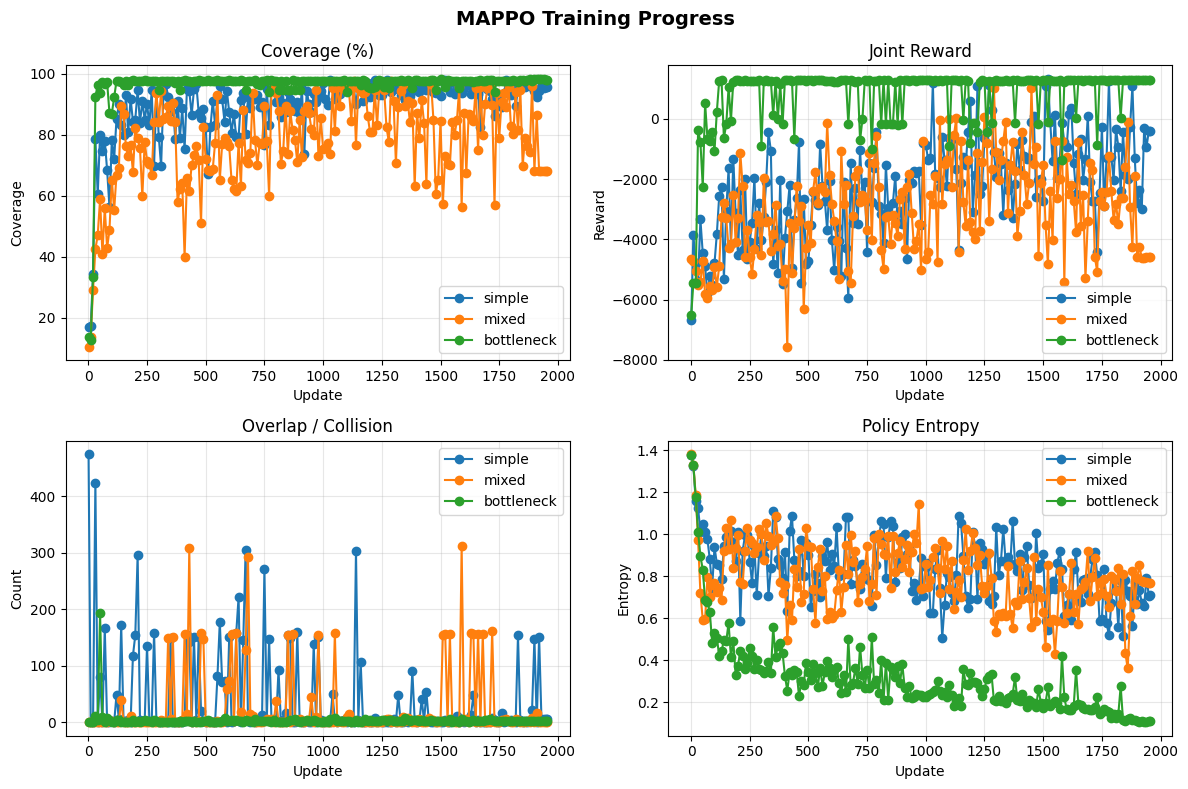

Saved -> training_progress.png


In [8]:
# -- 7c. Training progress plots ----------------------------------------------
def plot_training_progress(eval_history: list) -> None:
    if not eval_history:
        print("No eval history yet.")
        return

    updates = [r["update"] for r in eval_history]
    map_names = ["simple", "mixed", "bottleneck"]

    fig, axes = plt.subplots(2, 2, figsize=(12, 8))
    ax_cov, ax_reward, ax_overlap, ax_entropy = axes.flatten()

    for mname in map_names:
        cov_vals = [r["eval"][mname]["coverage"] for r in eval_history]
        r_vals = [r["eval"][mname]["joint_reward"] for r in eval_history]
        o_vals = [r["eval"][mname]["overlap"] for r in eval_history]
        e_vals = [r["eval"][mname]["entropy"] for r in eval_history]
        ax_cov.plot(updates, cov_vals, marker="o", label=mname)
        ax_reward.plot(updates, r_vals, marker="o", label=mname)
        ax_overlap.plot(updates, o_vals, marker="o", label=mname)
        ax_entropy.plot(updates, e_vals, marker="o", label=mname)

    ax_cov.set_title("Coverage (%)")
    ax_cov.set_xlabel("Update")
    ax_cov.set_ylabel("Coverage")
    ax_cov.grid(True, alpha=0.3)
    ax_cov.legend()

    ax_reward.set_title("Joint Reward")
    ax_reward.set_xlabel("Update")
    ax_reward.set_ylabel("Reward")
    ax_reward.grid(True, alpha=0.3)
    ax_reward.legend()

    ax_overlap.set_title("Overlap / Collision")
    ax_overlap.set_xlabel("Update")
    ax_overlap.set_ylabel("Count")
    ax_overlap.grid(True, alpha=0.3)
    ax_overlap.legend()

    ax_entropy.set_title("Policy Entropy")
    ax_entropy.set_xlabel("Update")
    ax_entropy.set_ylabel("Entropy")
    ax_entropy.grid(True, alpha=0.3)
    ax_entropy.legend()

    plt.suptitle("MAPPO Training Progress", fontsize=14, fontweight="bold")
    plt.tight_layout()
    plt.savefig(f"{BACKUP_DIR}/training_progress.png", dpi=120)
    plt.show()
    print("Saved -> training_progress.png")


plot_training_progress(trainer.eval_history)


=== Final State ===
   0 1 2 3 4 5 6 7 8 9
 0 * * * * * * * * * *
 1 * * * * * * * * 1 *
 2 * * # # * * * * * *
 3 * * * * * * * * * *
 4 # # # # * # # # # #
 5 * * * * * 0 * * * .
 6 * * * * * * # # * .
 7 * * * * * * * * * *
 8 * # # # * * * * * *
 9 * * * * * * * * * *
Coverage: 97.6%  Steps: 56  UAV0: [5, 5]  UAV1: [1, 8]


Trajectory  (agent-0: lowercase, agent-1: UPPERCASE)
R S T U V W X Y Z Z
Q Z Z Z Z Z Z Z Z Z
Z Z # # Z Z Z Z Z Z
Z Z Z Z Z Z G H Z Z
# # # # Z # # # # #
z z A B C z n o p  
z h i j z z # # q  
z g f e z z z z z z
z # # # z z z z z z
z z z y x w v u z z


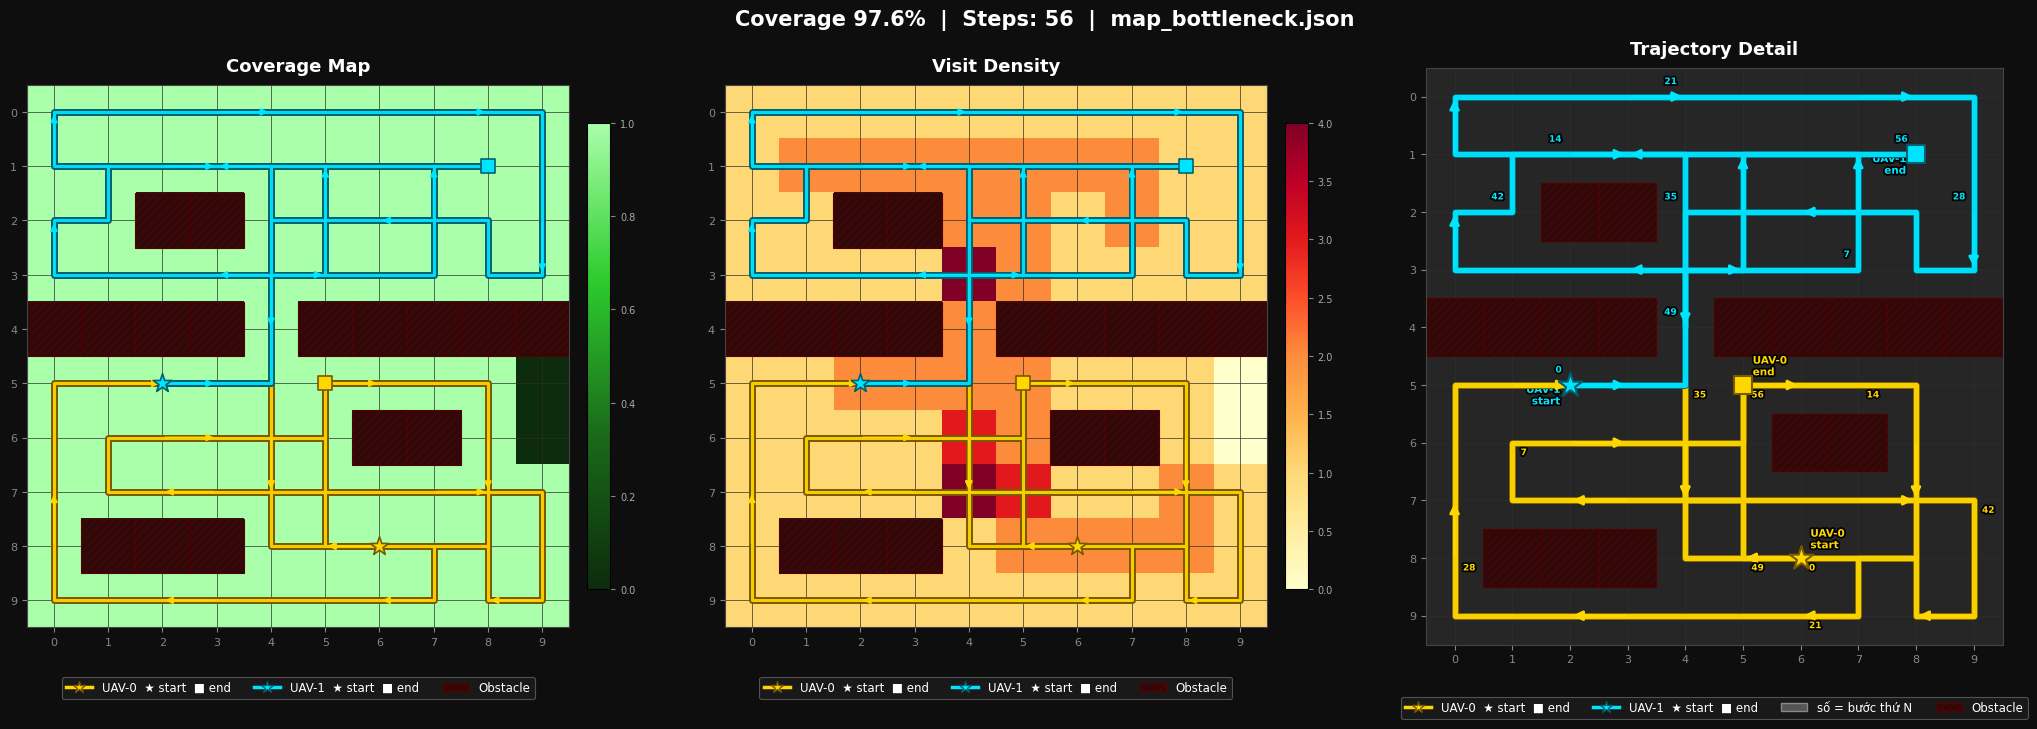

Saved → /kaggle/working/checkpoints_mappo/mappo_coverage_heatmap.png


In [9]:
# -- 7d. Render one episode with trajectory ----------------------------------
def render_episode(trainer: MAPPOTrainer, map_file: str, seed: int = 0) -> None:
    env = UAVPatrolEnvIPPO(map_file=map_file)
    obs, _ = env.reset(seed=seed)
    done = False
    while not done:
        obs_batch = np.stack([obs[0], obs[1]], axis=0)
        with torch.no_grad():
            actions, _, _ = trainer._policy(obs_batch, deterministic=True)
        obs, _, t, tr, _ = env.step([int(actions[0]), int(actions[1])])
        done = t or tr
    print("\n=== Final State ===")
    env.render()
    print()
    env.render_trajectory()


# -- 7e. Coverage heatmap: legend nằm dưới mỗi panel, màu UAV tách biệt -----
def plot_coverage_heatmap(trainer: MAPPOTrainer, map_file: str, seed: int = 0) -> None:
    import matplotlib.patches as mpatches
    import matplotlib.patheffects as pe
    from matplotlib.colors import LinearSegmentedColormap
    from matplotlib.lines import Line2D

    # ── Run episode ──────────────────────────────────────────────────────────
    env = UAVPatrolEnvIPPO(map_file=map_file)
    obs, _ = env.reset(seed=seed)
    done = False
    while not done:
        obs_batch = np.stack([obs[0], obs[1]], axis=0)
        with torch.no_grad():
            actions, _, _ = trainer._policy(obs_batch, deterministic=True)
        obs, _, t, tr, _ = env.step([int(actions[0]), int(actions[1])])
        done = t or tr

    g       = env.grid_size
    cov_pct = env.coverage.sum() / env.free_cells
    n_steps = env.steps

    # ── Màu UAV: vàng rực vs cyan sáng — tương phản tối đa trên nền tối ────
    UAV_COLORS  = ["#FFD700", "#00E5FF"]   # gold / electric cyan
    UAV_OUTLINES= ["#7A5800", "#006070"]   # viền tối cùng tone
    UAV_LABELS  = ["UAV-0",   "UAV-1"]
    OBS_COLOR   = "#2A0A0A"
    OBS_HATCH   = "////"
    ARROW_EVERY = max(1, n_steps // 12)
    LABEL_EVERY = max(1, n_steps // 8)

    # ── Build arrays ─────────────────────────────────────────────────────────
    obs_mask   = np.zeros((g, g), dtype=bool)
    for o in env.obstacles:
        obs_mask[o] = True
    cov_disp   = np.where(obs_mask, np.nan, env.coverage.astype(float))
    visit_disp = np.where(obs_mask, np.nan, env.visit_count.astype(float))

    cov_cmap = LinearSegmentedColormap.from_list(
        "cov", ["#0D2B0D", "#1A6B1A", "#2ECC2E", "#AAFFAA"], N=256
    )

    # ── Figure 1 row × 3 panels ──────────────────────────────────────────────
    fig, axes_row = plt.subplots(
        1, 3, figsize=(21, 7.5), facecolor="#0E0E0E"
    )
    fig.patch.set_facecolor("#0E0E0E")

    panel_titles = ["Coverage Map", "Visit Density", "Trajectory Detail"]
    axes = list(axes_row)

    for ax, title in zip(axes, panel_titles):
        ax.set_facecolor("#1C1C1C")
        ax.set_title(title, color="white", fontsize=13,
                     fontweight="bold", pad=10)
        ax.set_xticks(range(g));  ax.set_yticks(range(g))
        ax.tick_params(colors="#888888", labelsize=8)
        ax.grid(True, color="#2E2E2E", linewidth=0.5, zorder=0)
        for sp in ax.spines.values():
            sp.set_edgecolor("#444444")

    ax_cov, ax_vis, ax_traj = axes

    # ── Helper: obstacle overlay ─────────────────────────────────────────────
    def _draw_obstacles(ax):
        for (r, c) in env.obstacles:
            ax.add_patch(plt.Rectangle(
                (c - 0.5, r - 0.5), 1, 1,
                facecolor=OBS_COLOR, hatch=OBS_HATCH,
                edgecolor="#550000", linewidth=0.8, zorder=2
            ))

    # ── Helper: legend dưới mỗi panel ────────────────────────────────────────
    def _add_legend(ax, show_steps=False):
        handles = []
        for color, label in zip(UAV_COLORS, UAV_LABELS):
            handles.append(Line2D(
                [0], [0], color=color, linewidth=2.5,
                marker="*", markersize=9,
                markerfacecolor=color, markeredgecolor=UAV_OUTLINES[UAV_COLORS.index(color)],
                label=f"{label}  ★ start  ■ end"
            ))
        if show_steps:
            handles.append(mpatches.Patch(
                facecolor="#555555", edgecolor="#888888",
                label="số = bước thứ N"
            ))
        handles.append(mpatches.Patch(
            facecolor=OBS_COLOR, hatch=OBS_HATCH,
            edgecolor="#550000", label="Obstacle"
        ))
        leg = ax.legend(
            handles=handles,
            loc="upper center",
            bbox_to_anchor=(0.5, -0.08),   # dưới panel, ngoài bản đồ
            ncol=len(handles),
            fontsize=8.5,
            facecolor="#1A1A1A",
            edgecolor="#555555",
            labelcolor="white",
            framealpha=0.95,
            handlelength=2.2,
        )
        leg.get_frame().set_linewidth(0.8)

    # ── Panel 1: Coverage ────────────────────────────────────────────────────
    im_cov = ax_cov.imshow(
        np.ma.masked_invalid(cov_disp),
        cmap=cov_cmap, vmin=0, vmax=1,
        origin="upper", interpolation="nearest"
    )
    _draw_obstacles(ax_cov)
    cb1 = plt.colorbar(im_cov, ax=ax_cov, fraction=0.04, pad=0.03)
    cb1.ax.yaxis.set_tick_params(color="#888888")
    plt.setp(cb1.ax.yaxis.get_ticklabels(), color="#AAAAAA", fontsize=7)

    # ── Panel 2: Visit density ────────────────────────────────────────────────
    im_vis = ax_vis.imshow(
        np.ma.masked_invalid(visit_disp),
        cmap="YlOrRd", origin="upper", interpolation="nearest"
    )
    _draw_obstacles(ax_vis)
    cb2 = plt.colorbar(im_vis, ax=ax_vis, fraction=0.04, pad=0.03)
    cb2.ax.yaxis.set_tick_params(color="#888888")
    plt.setp(cb2.ax.yaxis.get_ticklabels(), color="#AAAAAA", fontsize=7)

    # ── Panel 3: Trajectory detail ────────────────────────────────────────────
    free_bg = np.where(obs_mask, np.nan, 0.15)
    ax_traj.imshow(
        np.ma.masked_invalid(free_bg),
        cmap="gray", vmin=0, vmax=1,
        origin="upper", interpolation="nearest"
    )
    _draw_obstacles(ax_traj)

    # ── Vẽ trajectory lên cả 3 panel ─────────────────────────────────────────
    for i, (traj, color, outline) in enumerate(
        zip(env.trajectory, UAV_COLORS, UAV_OUTLINES)
    ):
        xs = np.array([p[1] for p in traj], dtype=float)
        ys = np.array([p[0] for p in traj], dtype=float)
        stroke_fx = [pe.Stroke(linewidth=5, foreground=outline), pe.Normal()]

        # Panel 1 & 2: đường mỏng + mũi tên + start/end marker
        for ax in (ax_cov, ax_vis):
            ax.plot(xs, ys, color=color, linewidth=2.2,
                    alpha=0.92, zorder=10, path_effects=stroke_fx)
            for k in range(0, len(xs) - 1, ARROW_EVERY):
                dx = xs[k+1] - xs[k]; dy = ys[k+1] - ys[k]
                if abs(dx) + abs(dy) < 0.01:
                    continue
                ax.annotate("",
                    xy=(xs[k+1], ys[k+1]), xytext=(xs[k], ys[k]),
                    arrowprops=dict(arrowstyle="-|>", color=color,
                                    lw=1.4, mutation_scale=10),
                    zorder=11)
            ax.scatter(xs[0],  ys[0],  color=color, marker="*", s=200,
                       zorder=12, edgecolors=outline, linewidths=1.2)
            ax.scatter(xs[-1], ys[-1], color=color, marker="s", s=100,
                       zorder=12, edgecolors=outline, linewidths=1.2)

        # Panel 3: đường dày + số bước + start/end label rõ
        ax_traj.plot(xs, ys, color=color, linewidth=3.8,
                     alpha=0.95, zorder=10, path_effects=stroke_fx)
        for k in range(0, len(xs) - 1, ARROW_EVERY):
            dx = xs[k+1] - xs[k]; dy = ys[k+1] - ys[k]
            if abs(dx) + abs(dy) < 0.01:
                continue
            ax_traj.annotate("",
                xy=(xs[k+1], ys[k+1]), xytext=(xs[k], ys[k]),
                arrowprops=dict(arrowstyle="-|>", color=color,
                                lw=2.0, mutation_scale=14),
                zorder=11)

        # Số bước — offset ngược hướng để 2 UAV không đè nhau
        txt_offset = (6, -9) if i == 0 else (-6, 9)
        txt_ha     = "left"  if i == 0 else "right"
        for k in range(0, len(xs), LABEL_EVERY):
            ax_traj.annotate(
                str(k), xy=(xs[k], ys[k]),
                xytext=txt_offset, textcoords="offset points",
                fontsize=6.5, color=color, fontweight="bold",
                ha=txt_ha, zorder=13,
                path_effects=[
                    pe.Stroke(linewidth=2.5, foreground="#000000"),
                    pe.Normal()
                ]
            )

        # Start ★ / End ■
        ax_traj.scatter(xs[0],  ys[0],  color=color, marker="*",
                        s=320, zorder=14, edgecolors=outline, linewidths=1.5)
        ax_traj.scatter(xs[-1], ys[-1], color=color, marker="s",
                        s=150, zorder=14, edgecolors=outline, linewidths=1.5)

        # Label start/end — offset ngược nhau
        lbl_offset = (7, 7) if i == 0 else (-7, -14)
        lbl_ha     = "left" if i == 0 else "right"
        ax_traj.annotate(
            f"{UAV_LABELS[i]}\nstart",
            xy=(xs[0], ys[0]),
            xytext=lbl_offset, textcoords="offset points",
            fontsize=7.5, color=color, fontweight="bold", ha=lbl_ha,
            path_effects=[pe.Stroke(linewidth=2.5, foreground="#000000"),
                          pe.Normal()]
        )
        ax_traj.annotate(
            f"{UAV_LABELS[i]}\nend",
            xy=(xs[-1], ys[-1]),
            xytext=lbl_offset, textcoords="offset points",
            fontsize=7.5, color=color, fontweight="bold", ha=lbl_ha,
            path_effects=[pe.Stroke(linewidth=2.5, foreground="#000000"),
                          pe.Normal()]
        )

    # ── Legend dưới mỗi panel (ngoài bản đồ) ─────────────────────────────────
    _add_legend(ax_cov,  show_steps=False)
    _add_legend(ax_vis,  show_steps=False)
    _add_legend(ax_traj, show_steps=True)

    # ── Super-title ───────────────────────────────────────────────────────────
    fig.suptitle(
        f"Coverage {cov_pct:.1%}  |  Steps: {n_steps}  |  {map_file.split('/')[-1]}",
        fontsize=15, fontweight="bold", color="white", y=1.01
    )

    # rect bottom=0.12 để chừa chỗ cho legend bên dưới
    plt.tight_layout(rect=[0, 0.12, 1, 1])

    out_path = f"{BACKUP_DIR}/mappo_coverage_heatmap.png"
    plt.savefig(out_path, dpi=150, bbox_inches="tight",
                facecolor=fig.get_facecolor())
    plt.show()
    print(f"Saved → {out_path}")


render_episode(trainer, MAP_PATHS["bottleneck"])
plot_coverage_heatmap(trainer, MAP_PATHS["bottleneck"])

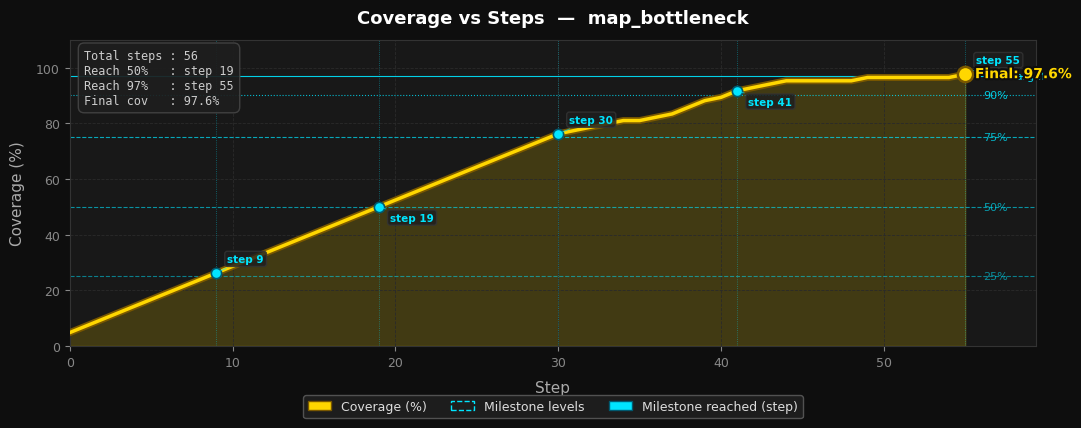

Saved → /kaggle/working/checkpoints_mappo/mappo_coverage_vs_steps.png


In [10]:
# -- Coverage vs Steps --------------------------------------------------------
def plot_coverage_vs_steps(trainer: MAPPOTrainer, map_file: str, seed: int = 0):
    import matplotlib.patches as mpatches
    import matplotlib.patheffects as pe
    from matplotlib.colors import LinearSegmentedColormap

    # ── Run episode ──────────────────────────────────────────────────────────
    env = UAVPatrolEnvIPPO(map_file=map_file)
    obs, _ = env.reset(seed=seed)
    done = False
    coverage_history = []
    milestone_steps  = {}   # step đạt các mốc 25/50/75/90/97%

    while not done:
        obs_batch = np.stack([obs[0], obs[1]], axis=0)
        with torch.no_grad():
            actions, _, _ = trainer._policy(obs_batch, deterministic=True)
        obs, _, t, tr, _ = env.step([int(actions[0]), int(actions[1])])
        cov = env.coverage.sum() / env.free_cells * 100
        coverage_history.append(cov)
        for m in [25, 50, 75, 90, 97]:
            if m not in milestone_steps and cov >= m:
                milestone_steps[m] = len(coverage_history) - 1
        done = t or tr

    steps     = np.arange(len(coverage_history))
    cov_arr   = np.array(coverage_history)
    final_cov = cov_arr[-1]
    map_name  = map_file.split("/")[-1].replace(".json", "")

    # ── Style ────────────────────────────────────────────────────────────────
    BG        = "#0E0E0E"
    PANEL     = "#181818"
    GRID_CLR  = "#2A2A2A"
    LINE_CLR  = "#FFD700"      # gold — tương phản trên nền tối
    FILL_TOP  = "#FFD70033"
    FILL_BOT  = "#FFD70005"
    MILE_CLR  = "#00E5FF"      # cyan cho milestone lines
    ANNO_BG   = "#1E1E1E"

    fig, ax = plt.subplots(figsize=(11, 5), facecolor=BG)
    ax.set_facecolor(PANEL)
    for sp in ax.spines.values():
        sp.set_edgecolor("#333333")

    # ── Gradient fill dưới đường ─────────────────────────────────────────────
    # Dùng polygon alpha thay gradient (matplotlib-safe)
    ax.fill_between(steps, cov_arr, alpha=0.18, color=LINE_CLR, zorder=1)

    # ── Đường chính với outline ───────────────────────────────────────────────
    stroke_fx = [pe.Stroke(linewidth=5, foreground="#7A5800"), pe.Normal()]
    ax.plot(steps, cov_arr, color=LINE_CLR, linewidth=2.5,
            zorder=5, path_effects=stroke_fx, label="Coverage")

    # ── Milestone horizontal lines ────────────────────────────────────────────
    mile_styles = {
        25: ("--", 0.5, "25%"),
        50: ("--", 0.6, "50%"),
        75: ("--", 0.7, "75%"),
        90: (  ":", 0.8, "90%"),
        97: (  "-", 0.9, "97% target"),
    }
    for m, (ls, alpha, lbl) in mile_styles.items():
        ax.axhline(m, color=MILE_CLR, linewidth=0.8,
                   linestyle=ls, alpha=alpha, zorder=2)
        ax.text(len(steps) * 1.002, m, lbl,
                color=MILE_CLR, fontsize=8, va="center",
                alpha=alpha + 0.05)

    # ── Vertical markers tại bước đạt milestone ───────────────────────────────
    for m, step_idx in milestone_steps.items():
        ax.axvline(step_idx, color=MILE_CLR, linewidth=0.6,
                   linestyle=":", alpha=0.45, zorder=2)
        ax.scatter(step_idx, cov_arr[step_idx],
                   color=MILE_CLR, s=55, zorder=8,
                   edgecolors="#005A70", linewidths=1.2)
        # Annotation box
        offset_y = -10 if m in [50, 90] else 8   # tránh đụng nhau
        ax.annotate(
            f"step {step_idx}",
            xy=(step_idx, cov_arr[step_idx]),
            xytext=(8, offset_y), textcoords="offset points",
            fontsize=7.5, color=MILE_CLR, fontweight="bold",
            bbox=dict(boxstyle="round,pad=0.25", fc=ANNO_BG,
                      ec="#333333", alpha=0.85),
            arrowprops=dict(arrowstyle="-", color=MILE_CLR,
                            lw=0.7, alpha=0.6),
            zorder=9,
        )

    # ── Điểm cuối nổi bật ────────────────────────────────────────────────────
    ax.scatter(steps[-1], final_cov, color=LINE_CLR, s=120,
               zorder=10, edgecolors="#7A5800", linewidths=1.8)
    ax.annotate(
        f"  Final: {final_cov:.1f}%",
        xy=(steps[-1], final_cov),
        fontsize=10, color=LINE_CLR, fontweight="bold",
        va="center",
        path_effects=[pe.Stroke(linewidth=3, foreground=BG), pe.Normal()],
        zorder=11,
    )

    # ── Axes ─────────────────────────────────────────────────────────────────
    ax.set_xlim(0, len(steps) * 1.06)
    ax.set_ylim(0, 110)
    ax.set_xlabel("Step", color="#AAAAAA", fontsize=11, labelpad=8)
    ax.set_ylabel("Coverage (%)", color="#AAAAAA", fontsize=11, labelpad=8)
    ax.tick_params(colors="#888888", labelsize=9)
    ax.grid(True, color=GRID_CLR, linewidth=0.6, linestyle="--",
            axis="both", zorder=0)

    # ── Stats box (góc trên trái) ─────────────────────────────────────────────
    total_steps = len(steps)
    step_50  = milestone_steps.get(50,  "—")
    step_97  = milestone_steps.get(97,  "—")
    stats_txt = (
        f"Total steps : {total_steps}\n"
        f"Reach 50%   : step {step_50}\n"
        f"Reach 97%   : step {step_97}\n"
        f"Final cov   : {final_cov:.1f}%"
    )
    ax.text(
        0.015, 0.97, stats_txt,
        transform=ax.transAxes,
        fontsize=8.5, color="#CCCCCC",
        va="top", ha="left", family="monospace",
        bbox=dict(boxstyle="round,pad=0.5", fc=ANNO_BG,
                  ec="#444444", alpha=0.92),
        zorder=12,
    )

    # ── Title ────────────────────────────────────────────────────────────────
    ax.set_title(
        f"Coverage vs Steps  —  {map_name}",
        fontsize=13, fontweight="bold", color="white", pad=12
    )

    # ── Legend dưới biểu đồ ──────────────────────────────────────────────────
    legend_handles = [
        mpatches.Patch(facecolor=LINE_CLR,  edgecolor="#7A5800",
                       label="Coverage (%)"),
        mpatches.Patch(facecolor="none",    edgecolor=MILE_CLR,
                       linestyle="--",      label="Milestone levels"),
        mpatches.Patch(facecolor=MILE_CLR,  edgecolor="#005A70",
                       label="Milestone reached (step)"),
    ]
    ax.legend(
        handles=legend_handles,
        loc="upper center",
        bbox_to_anchor=(0.5, -0.14),
        ncol=3,
        fontsize=9,
        facecolor=ANNO_BG,
        edgecolor="#555555",
        labelcolor="#DDDDDD",
        framealpha=0.95,
        handlelength=1.8,
    )

    plt.tight_layout(rect=[0, 0.10, 1, 1])

    out_path = f"{BACKUP_DIR}/mappo_coverage_vs_steps.png"
    plt.savefig(out_path, dpi=150, bbox_inches="tight",
                facecolor=fig.get_facecolor())
    plt.show()
    print(f"Saved → {out_path}")


plot_coverage_vs_steps(trainer, MAP_PATHS["bottleneck"])

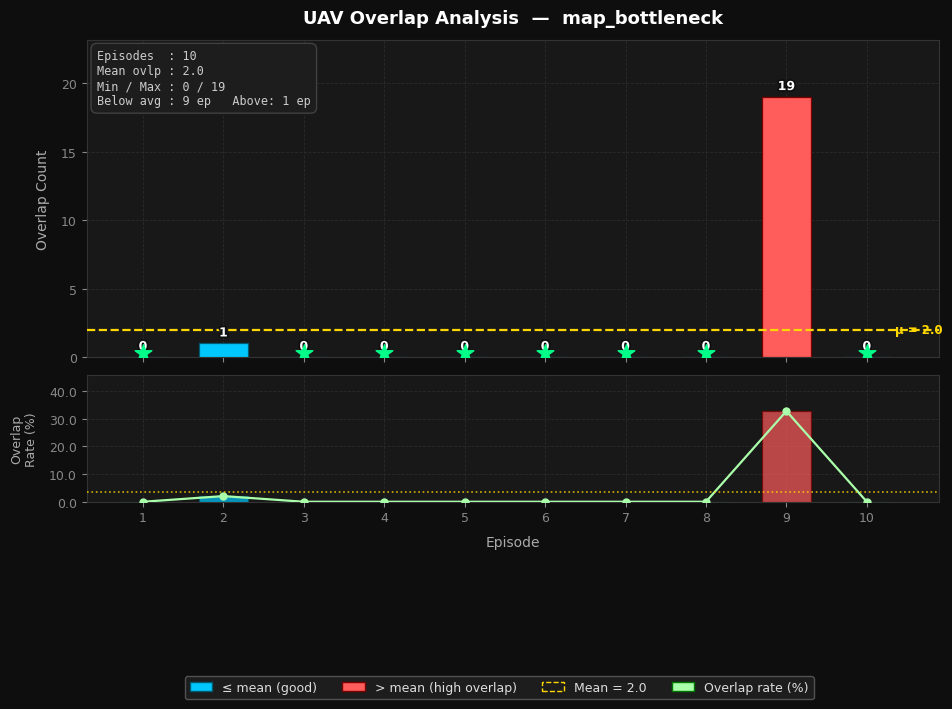

Saved → /kaggle/working/checkpoints_mappo/mappo_overlap_analysis.png


In [11]:
# -- Overlap Analysis ---------------------------------------------------------
def plot_overlap_analysis(trainer: MAPPOTrainer, map_file: str, episodes: int = 10):
    import matplotlib.patches as mpatches
    import matplotlib.patheffects as pe
    import matplotlib.ticker as ticker

    # ── Run episodes, collect per-episode stats ───────────────────────────────
    overlap_counts  = []
    coverage_finals = []
    step_counts     = []

    for ep in range(episodes):
        env = UAVPatrolEnvIPPO(map_file=map_file)
        obs, _ = env.reset(seed=ep)
        done = False
        overlap = 0
        while not done:
            obs_batch = np.stack([obs[0], obs[1]], axis=0)
            with torch.no_grad():
                actions, _, _ = trainer._policy(obs_batch, deterministic=True)
            obs, _, t, tr, _ = env.step([int(actions[0]), int(actions[1])])
            p0, p1 = env.agent_positions
            if check_collision(p0, p1) or check_overlap(p0, p1):
                overlap += 1
            done = t or tr
        overlap_counts.append(overlap)
        coverage_finals.append(env.coverage.sum() / env.free_cells * 100)
        step_counts.append(env.steps)

    eps       = np.arange(1, episodes + 1)
    counts    = np.array(overlap_counts, dtype=float)
    mean_ovlp = counts.mean()
    map_name  = map_file.split("/")[-1].replace(".json", "")

    # ── Style ─────────────────────────────────────────────────────────────────
    BG       = "#0E0E0E"
    PANEL    = "#181818"
    GRID_CLR = "#2A2A2A"
    ANNO_BG  = "#1E1E1E"

    # Bar colour: cyan nếu dưới mean, coral nếu trên mean
    BAR_LOW  = "#00C8FF"   # dưới trung bình → tốt
    BAR_HIGH = "#FF5C5C"   # trên trung bình → xấu
    MEAN_CLR = "#FFD700"   # gold cho đường mean
    RATE_CLR = "#AAFFAA"   # xanh lá nhạt cho overlap rate

    bar_colors = [BAR_HIGH if c > mean_ovlp else BAR_LOW for c in counts]
    outline_colors = ["#7A0000" if c == BAR_HIGH else "#005A70"
                      for c in bar_colors]

    # ── Figure: 2 panels (bar + rate line) ────────────────────────────────────
    fig, (ax_bar, ax_rate) = plt.subplots(
        2, 1, figsize=(11, 7),
        facecolor=BG,
        gridspec_kw={"height_ratios": [3, 1.2], "hspace": 0.08}
    )
    for ax in (ax_bar, ax_rate):
        ax.set_facecolor(PANEL)
        for sp in ax.spines.values():
            sp.set_edgecolor("#333333")
        ax.grid(True, color=GRID_CLR, linewidth=0.6,
                linestyle="--", zorder=0)
        ax.tick_params(colors="#888888", labelsize=9)

    # ── Panel 1: Bar chart ────────────────────────────────────────────────────
    bars = ax_bar.bar(
        eps, counts,
        color=bar_colors, edgecolor=outline_colors,
        linewidth=0.9, width=0.6, zorder=4
    )

    # Value label trên mỗi bar
    for bar, val in zip(bars, counts):
        ypos = bar.get_height() + max(counts) * 0.015
        ax_bar.text(
            bar.get_x() + bar.get_width() / 2, ypos,
            str(int(val)),
            ha="center", va="bottom",
            fontsize=9, fontweight="bold", color="white",
            path_effects=[pe.Stroke(linewidth=2.5, foreground=BG),
                          pe.Normal()],
            zorder=6
        )

    # Mean line
    ax_bar.axhline(mean_ovlp, color=MEAN_CLR, linewidth=1.6,
                   linestyle="--", zorder=5, label=f"Mean {mean_ovlp:.1f}")
    ax_bar.text(
        episodes + 0.35, mean_ovlp,
        f"μ = {mean_ovlp:.1f}",
        color=MEAN_CLR, fontsize=8.5, va="center", fontweight="bold"
    )

    # Zero-overlap marker nếu có episode nào = 0
    zero_eps = [e for e, c in zip(eps, counts) if c == 0]
    if zero_eps:
        ax_bar.scatter(zero_eps, [0.3] * len(zero_eps),
                       color="#00FF88", marker="*", s=160,
                       zorder=7, label="Zero overlap")

    ax_bar.set_xlim(0.3, episodes + 0.9)
    ax_bar.set_ylim(0, max(counts) * 1.22 if max(counts) > 0 else 5)
    ax_bar.set_ylabel("Overlap Count", color="#AAAAAA", fontsize=10, labelpad=8)
    ax_bar.set_xticks(eps)
    ax_bar.set_xticklabels([])   # ẩn, panel dưới đã có

    ax_bar.set_title(
        f"UAV Overlap Analysis  —  {map_name}",
        fontsize=13, fontweight="bold", color="white", pad=12
    )

    # Stats box
    n_low  = sum(1 for c in counts if c <= mean_ovlp)
    n_high = episodes - n_low
    stats_txt = (
        f"Episodes  : {episodes}\n"
        f"Mean ovlp : {mean_ovlp:.1f}\n"
        f"Min / Max : {int(min(counts))} / {int(max(counts))}\n"
        f"Below avg : {n_low} ep   Above: {n_high} ep"
    )
    ax_bar.text(
        0.012, 0.97, stats_txt,
        transform=ax_bar.transAxes,
        fontsize=8.5, color="#CCCCCC",
        va="top", ha="left", family="monospace",
        bbox=dict(boxstyle="round,pad=0.5", fc=ANNO_BG,
                  ec="#444444", alpha=0.92),
        zorder=8,
    )

    # ── Panel 2: Overlap rate (%) per episode ─────────────────────────────────
    rates = counts / np.array(step_counts) * 100   # overlap / total steps

    ax_rate.bar(eps, rates, color=bar_colors, edgecolor=outline_colors,
                linewidth=0.9, width=0.6, alpha=0.7, zorder=4)
    ax_rate.plot(eps, rates, color=RATE_CLR, linewidth=1.6,
                 marker="o", markersize=5, zorder=5)
    ax_rate.axhline(rates.mean(), color=MEAN_CLR, linewidth=1.2,
                    linestyle=":", alpha=0.8, zorder=5)

    ax_rate.set_xlim(0.3, episodes + 0.9)
    ax_rate.set_ylim(0, max(rates) * 1.4 if max(rates) > 0 else 1)
    ax_rate.set_ylabel("Overlap\nRate (%)", color="#AAAAAA",
                       fontsize=9, labelpad=8)
    ax_rate.set_xlabel("Episode", color="#AAAAAA", fontsize=10, labelpad=8)
    ax_rate.set_xticks(eps)
    ax_rate.yaxis.set_major_formatter(ticker.FormatStrFormatter("%.1f"))

    # ── Legend dưới biểu đồ ───────────────────────────────────────────────────
    legend_handles = [
        mpatches.Patch(facecolor=BAR_LOW,  edgecolor="#005A70",
                       label=f"≤ mean (good)"),
        mpatches.Patch(facecolor=BAR_HIGH, edgecolor="#7A0000",
                       label=f"> mean (high overlap)"),
        mpatches.Patch(facecolor="none",   edgecolor=MEAN_CLR,
                       linestyle="--",     label=f"Mean = {mean_ovlp:.1f}"),
        mpatches.Patch(facecolor=RATE_CLR, edgecolor="#007700",
                       label="Overlap rate (%)"),
    ]
    fig.legend(
        handles=legend_handles,
        loc="upper center",
        bbox_to_anchor=(0.5, -0.02),
        ncol=4,
        fontsize=9,
        facecolor=ANNO_BG,
        edgecolor="#555555",
        labelcolor="#DDDDDD",
        framealpha=0.95,
        handlelength=1.8,
    )

    fig.subplots_adjust(bottom=0.22)

    out_path = f"{BACKUP_DIR}/mappo_overlap_analysis.png"
    plt.savefig(out_path, dpi=150, bbox_inches="tight",
                facecolor=fig.get_facecolor())
    plt.show()
    print(f"Saved → {out_path}")


plot_overlap_analysis(trainer, MAP_PATHS["bottleneck"])

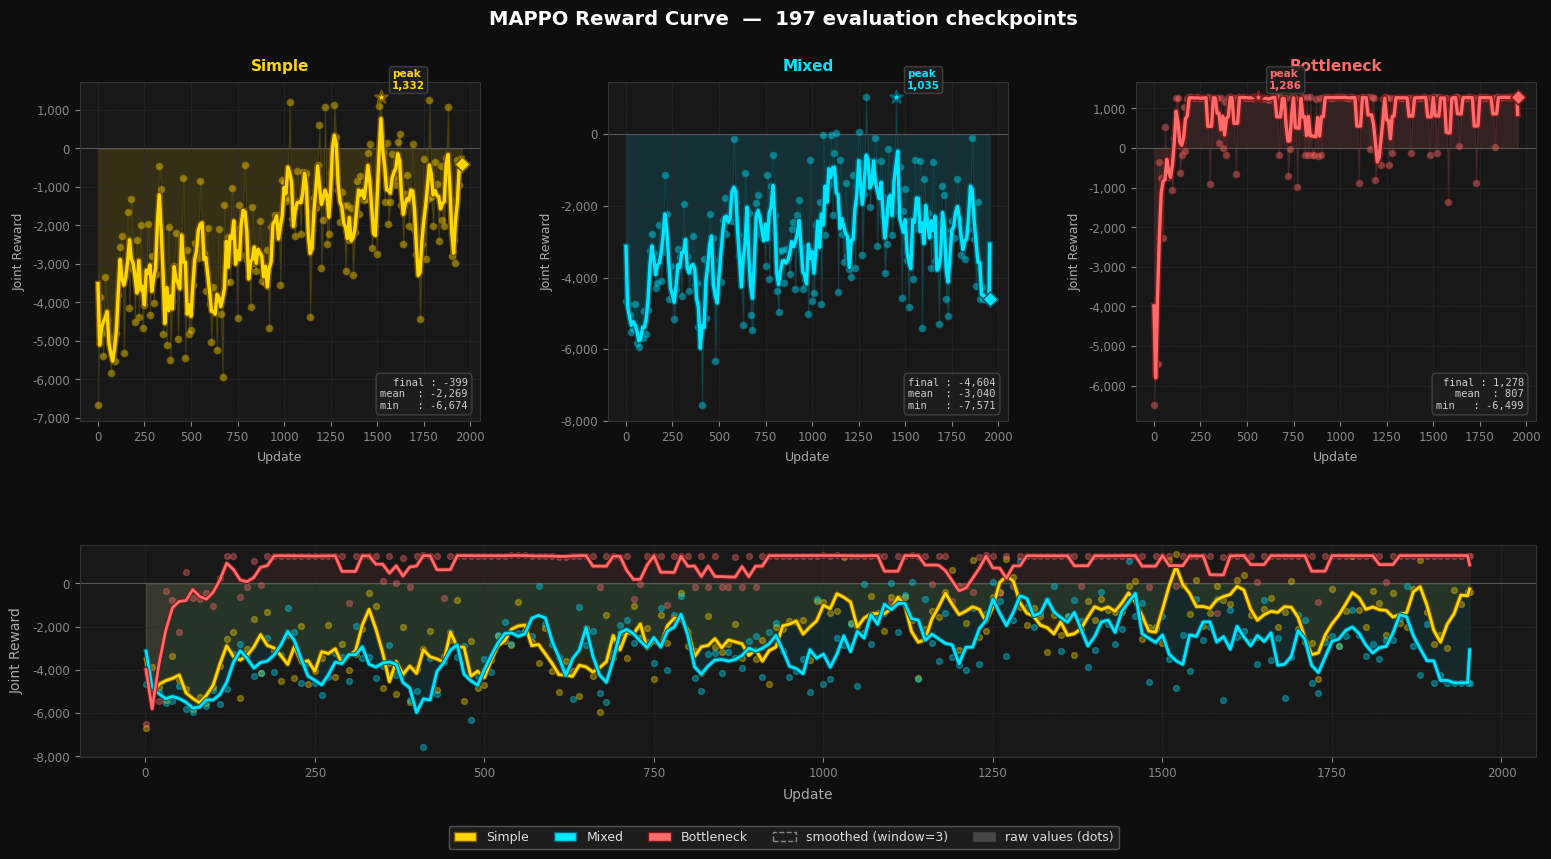

Saved → /kaggle/working/checkpoints_mappo/mappo_reward_curve.png


In [12]:
# -- Reward Curve -------------------------------------------------------------
def plot_reward_curve(eval_history):
    if not eval_history:
        print("No eval history.")
        return

    import matplotlib.patches as mpatches
    import matplotlib.patheffects as pe
    import matplotlib.ticker as ticker
    from matplotlib.gridspec import GridSpec

    # ── Data ─────────────────────────────────────────────────────────────────
    updates   = [r["update"] for r in eval_history]
    map_names = ["simple", "mixed", "bottleneck"]
    map_colors = {
        "simple":     "#FFD700",   # gold
        "mixed":      "#00E5FF",   # cyan
        "bottleneck": "#FF6B6B",   # coral
    }
    map_outlines = {
        "simple":     "#7A5800",
        "mixed":      "#006070",
        "bottleneck": "#7A1A1A",
    }

    # ── Style ─────────────────────────────────────────────────────────────────
    BG       = "#0E0E0E"
    PANEL    = "#181818"
    GRID_CLR = "#2A2A2A"
    ANNO_BG  = "#1E1E1E"

    # ── Figure: 3 panels trên + 1 panel tổng hợp dưới ────────────────────────
    fig = plt.figure(figsize=(16, 9), facecolor=BG)
    fig.patch.set_facecolor(BG)

    gs = GridSpec(
        2, 3,
        figure=fig,
        hspace=0.45, wspace=0.32,
        top=0.88, bottom=0.13,
        left=0.06, right=0.97,
        height_ratios=[1.6, 1.0],
    )

    axes_top    = [fig.add_subplot(gs[0, i]) for i in range(3)]
    ax_combined = fig.add_subplot(gs[1, :])   # full-width bottom panel

    # ── Helper: style one axes ────────────────────────────────────────────────
    def _style(ax):
        ax.set_facecolor(PANEL)
        for sp in ax.spines.values():
            sp.set_edgecolor("#333333")
        ax.grid(True, color=GRID_CLR, linewidth=0.55,
                linestyle="--", zorder=0)
        ax.tick_params(colors="#888888", labelsize=8.5)

    for ax in axes_top + [ax_combined]:
        _style(ax)

    # ── Helper: smooth line (running mean window) ─────────────────────────────
    def _smooth(arr, w=3):
        if len(arr) < w:
            return np.array(arr, dtype=float)
        kernel = np.ones(w) / w
        return np.convolve(arr, kernel, mode="same")

    # ── Panel trên: 1 map per panel ───────────────────────────────────────────
    for ax, mname in zip(axes_top, map_names):
        color   = map_colors[mname]
        outline = map_outlines[mname]
        rewards = np.array([r["eval"][mname]["joint_reward"]
                            for r in eval_history], dtype=float)
        smooth  = _smooth(rewards, w=3)
        stroke  = [pe.Stroke(linewidth=4.5, foreground=outline), pe.Normal()]

        # Fill dưới đường
        ax.fill_between(updates, rewards, alpha=0.12, color=color, zorder=1)

        # Raw dots mờ
        ax.scatter(updates, rewards, color=color, s=28, alpha=0.45,
                   zorder=3, edgecolors=outline, linewidths=0.6)

        # Smoothed line nổi bật
        ax.plot(updates, smooth, color=color, linewidth=2.4,
                zorder=4, path_effects=stroke)

        # Đỉnh cao nhất
        peak_idx = int(np.argmax(rewards))
        ax.scatter(updates[peak_idx], rewards[peak_idx],
                   color=color, s=90, zorder=6,
                   edgecolors=outline, linewidths=1.5,
                   marker="*")
        ax.annotate(
            f"peak\n{rewards[peak_idx]:,.0f}",
            xy=(updates[peak_idx], rewards[peak_idx]),
            xytext=(8, 6), textcoords="offset points",
            fontsize=7.5, color=color, fontweight="bold",
            bbox=dict(boxstyle="round,pad=0.25", fc=ANNO_BG,
                      ec="#444444", alpha=0.88),
            zorder=7,
        )

        # Điểm cuối
        ax.scatter(updates[-1], rewards[-1],
                   color=color, s=60, zorder=6,
                   edgecolors=outline, linewidths=1.2,
                   marker="D")

        # Stats box — góc dưới bên phải, trong axes
        stats = (
            f"final : {rewards[-1]:,.0f}\n"
            f"mean  : {rewards.mean():,.0f}\n"
            f"min   : {rewards.min():,.0f}"
        )
        ax.text(
            0.97, 0.03, stats,
            transform=ax.transAxes,
            fontsize=7.5, color="#CCCCCC",
            va="bottom", ha="right", family="monospace",
            bbox=dict(boxstyle="round,pad=0.4", fc=ANNO_BG,
                      ec="#444444", alpha=0.90),
            zorder=8,
        )

        # Zero line nếu reward âm tồn tại
        if rewards.min() < 0 < rewards.max():
            ax.axhline(0, color="#555555", linewidth=0.8,
                       linestyle="-", zorder=2)

        ax.set_title(
            mname.capitalize(),
            fontsize=11, fontweight="bold",
            color=color, pad=8
        )
        ax.set_xlabel("Update", color="#AAAAAA", fontsize=9, labelpad=5)
        ax.set_ylabel("Joint Reward", color="#AAAAAA", fontsize=9, labelpad=5)
        ax.yaxis.set_major_formatter(
            ticker.FuncFormatter(lambda x, _: f"{x:,.0f}")
        )

    # ── Panel dưới: 3 map trên cùng trục (overview) ──────────────────────────
    for mname in map_names:
        color   = map_colors[mname]
        outline = map_outlines[mname]
        rewards = np.array([r["eval"][mname]["joint_reward"]
                            for r in eval_history], dtype=float)
        smooth  = _smooth(rewards, w=3)
        stroke  = [pe.Stroke(linewidth=3.5, foreground=outline), pe.Normal()]

        ax_combined.fill_between(updates, smooth,
                                 alpha=0.08, color=color, zorder=1)
        ax_combined.plot(updates, smooth, color=color, linewidth=2.0,
                         zorder=4, path_effects=stroke, label=mname.capitalize())
        ax_combined.scatter(updates, rewards, color=color, s=18,
                            alpha=0.35, zorder=3)

    if any(
        [r["eval"][m]["joint_reward"] for r in eval_history
         for m in map_names if r["eval"][m]["joint_reward"] < 0]
    ):
        ax_combined.axhline(0, color="#555555", linewidth=0.8,
                            linestyle="-", zorder=2)

    ax_combined.set_xlabel("Update", color="#AAAAAA", fontsize=10, labelpad=6)
    ax_combined.set_ylabel("Joint Reward", color="#AAAAAA",
                            fontsize=10, labelpad=6)
    ax_combined.yaxis.set_major_formatter(
        ticker.FuncFormatter(lambda x, _: f"{x:,.0f}")
    )

    # ── Legend dưới combined panel ────────────────────────────────────────────
    legend_handles = [
        mpatches.Patch(facecolor=map_colors[m], edgecolor=map_outlines[m],
                       label=m.capitalize())
        for m in map_names
    ] + [
        mpatches.Patch(facecolor="none", edgecolor="#888888",
                       linestyle="--", label="smoothed (window=3)"),
        mpatches.Patch(facecolor="#888888", edgecolor="#555555",
                       alpha=0.4, label="raw values (dots)"),
    ]
    fig.legend(
        handles=legend_handles,
        loc="upper center",
        bbox_to_anchor=(0.5, 0.06),
        ncol=len(legend_handles),
        fontsize=9,
        facecolor=ANNO_BG,
        edgecolor="#555555",
        labelcolor="#DDDDDD",
        framealpha=0.95,
        handlelength=1.8,
    )

    # ── Super title ───────────────────────────────────────────────────────────
    n_updates = len(updates)
    fig.suptitle(
        f"MAPPO Reward Curve  —  {n_updates} evaluation checkpoints",
        fontsize=14, fontweight="bold", color="white", y=0.96
    )

    out_path = f"{BACKUP_DIR}/mappo_reward_curve.png"
    plt.savefig(out_path, dpi=150, bbox_inches="tight",
                facecolor=fig.get_facecolor())
    plt.show()
    print(f"Saved → {out_path}")


plot_reward_curve(trainer.eval_history)

In [14]:
# ── Save All Experiment Artifacts ─────────────────────────────────────────────
import os, json, shutil, tarfile, datetime
import torch

EXPORT_DIR  = "/kaggle/working/mappo_experiment_export"
ARCHIVE_OUT = "/kaggle/working/mappo_experiment.tar.gz"
os.makedirs(EXPORT_DIR, exist_ok=True)

# 1. Model weights
for tag in ["mappo_uav_final"]:
    for role in ["actor", "critic"]:
        src = f"{BACKUP_DIR}/{tag}_{role}.pt"
        if os.path.exists(src):
            shutil.copy(src, EXPORT_DIR)

# 2. All .pt files in BACKUP_DIR (intermediate checkpoints)
for fname in os.listdir(BACKUP_DIR):
    if fname.endswith(".pt"):
        shutil.copy(os.path.join(BACKUP_DIR, fname), EXPORT_DIR)

# 3. Training log (eval_history)
log_path = os.path.join(EXPORT_DIR, "eval_history.json")
with open(log_path, "w") as f:
    json.dump(trainer.eval_history, f, indent=2)

# 4. Hyperparameters / config snapshot
config_snapshot = {
    "timestamp":    datetime.datetime.now().isoformat(),
    "MASTER_SEED":  MASTER_SEED,
    "DEVICE":       str(DEVICE),
    "BACKUP_DIR":   BACKUP_DIR,
    "MAP_PATHS":    MAP_PATHS,

    "RewardConfig": {
        k: v for k, v in vars(RewardConfig).items()
        if not k.startswith("__")
    },

    "trainer_kwargs": {
        "n_envs":        getattr(trainer, "n_envs", None),
        "n_steps":       getattr(trainer, "n_steps", None),
        "n_updates":     getattr(trainer, "n_updates", None),
        "gamma":         getattr(trainer, "gamma", None),
        "gae_lambda":    getattr(trainer, "gae_lambda", None),
        "clip_eps":      getattr(trainer, "clip_eps", None),
        "lr":            getattr(trainer, "lr", None),
        "n_epochs":      getattr(trainer, "n_epochs", None),
        "batch_size":    getattr(trainer, "batch_size", None),
        "ent_coef":      getattr(trainer, "ent_coef", None),
        "vf_coef":       getattr(trainer, "vf_coef", None),
        "max_grad_norm": getattr(trainer, "max_grad_norm", None),
    },
}
with open(os.path.join(EXPORT_DIR, "config.json"), "w") as f:
    json.dump(config_snapshot, f, indent=2, default=str)

# 5. Map configs
maps_dst = os.path.join(EXPORT_DIR, "maps")
if os.path.exists("/kaggle/working/maps"):
    shutil.copytree("/kaggle/working/maps", maps_dst, dirs_exist_ok=True)

# 6. Pack everything into a single .tar.gz
with tarfile.open(ARCHIVE_OUT, "w:gz") as tar:
    tar.add(EXPORT_DIR, arcname="mappo_experiment")

size_mb = os.path.getsize(ARCHIVE_OUT) / 1_048_576
print(f"✓  Archive saved → {ARCHIVE_OUT}  ({size_mb:.2f} MB)")
print(f"   Contents of {EXPORT_DIR}:")
for fname in sorted(os.listdir(EXPORT_DIR)):
    fpath = os.path.join(EXPORT_DIR, fname)
    sz    = os.path.getsize(fpath) if os.path.isfile(fpath) else 0
    print(f"     {fname:40s}  {sz/1024:.1f} KB")

✓  Archive saved → /kaggle/working/mappo_experiment.tar.gz  (1.13 MB)
   Contents of /kaggle/working/mappo_experiment_export:
     config.json                               1.0 KB
     eval_history.json                         204.7 KB
     mappo_uav_final_actor.pt                  513.2 KB
     mappo_uav_final_critic.pt                 694.8 KB
     maps                                      0.0 KB
